# Validation : la matrice de contagion VAR a-t-elle du sens ?

146 actions US, log-returns 30 min, 2019-04 → 2023-05 (T = 13 360, mean |ρ| = 0.38).
On veut une **matrice de contagion** crédible — pas un prédicteur. Donc l'OOS R²
n'est pas le bon test (le VAR n'a aucune raison d'extrapoler entre régimes).

Tests retenus, tous *in-sample*, comparés à trois benchmarks de null. **Le rôle
de chaque null est crucial** :

| Null | Préserve | Casse | Ce qu'il teste |
|---|---|---|---|
| **Gaussien i.i.d.** | vol par actif | autocorr + cross-corr | baseline absolue |
| **Phase-randomized** (Theiler 1992, Algo. 1) | spectre de puissance ⇒ autocorr | distribution marginale + cross-corr | est-ce que l'autocorr seule suffit ? |
| **Block bootstrap** | corrélations contemporaines | dynamique temporelle | est-ce que la matrice ne fait que recoder de la corr contemporaine ? |

Le block-bootstrap est le **null le plus instructif** : si la matrice VAR sur
block-boot ressemble à la matrice sur real, alors les coefs lagged ne capturent
pas vraiment de dynamique — juste de la cross-corrélation contemporaine déguisée.

Pas de masque de corrélation. Full VAR(p), OLS.

## 1. Setup et chargement

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
from functions import * 

from functions import load_data

%matplotlib inline
%config InlineBackend.figure_format='retina'

rng = np.random.default_rng(42)


def fit_subset_var(data, lags):
    """Fit subset VAR : r_t = c + sum_{k in lags} A_k · r_{t-k} + eps.

    Parameters
    ----------
    data : DataFrame ou ndarray, shape (T, N)
    lags : list[int]
        Lags inclus, ex. [1] pour VAR(1), [13] pour subset {13}, [1, 13] pour {1, 13}.

    Returns
    -------
    A_blocks : dict {lag: ndarray (N, N)}
        entree (i, j) = effet de asset_i.L_lag sur asset_j.
    resid : ndarray, shape (T - max(lags), N)
    Sigma : ndarray, shape (N, N)
        Covariance des résidus.
    Y : ndarray, shape (T - max(lags), N)
        Cible alignée.
    B : ndarray, shape (1 + len(lags)*N, N)
        Coefficients complets, ligne 0 = constante.
    """
    arr = data.values if hasattr(data, 'values') else data
    T_, N_ = arr.shape
    p_max = max(lags)
    n = T_ - p_max
    X = np.empty((n, len(lags) * N_ + 1))
    X[:, 0] = 1.0
    for i, k in enumerate(lags):
        X[:, 1 + i * N_ : 1 + (i + 1) * N_] = arr[p_max - k : T_ - k]
    Y = arr[p_max:]
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ B
    Sigma = resid.T @ resid / max(n - X.shape[1], 1)
    A_blocks = {k: B[1 + i * N_ : 1 + (i + 1) * N_] for i, k in enumerate(lags)}
    return A_blocks, resid, Sigma, Y, B

In [134]:
real = load_data(['stock'], log_returns=True, sort_by_sector=True)
asset_names = real.columns.tolist()
N = len(asset_names)
T = len(real)

sectors_df = pd.read_excel('data/stock_category.xlsx')
sector_map = sectors_df.set_index('Stocks')['Sectors'].to_dict()
sector_arr = np.array([sector_map.get(a, 'autre') for a in asset_names])

print(f'Actifs   : {N}')
print(f'Obs.     : {T}')
print(f'Periode  : {real.index[0].date()} -> {real.index[-1].date()}')
print(f'Mean |rho| off-diag : {np.abs(np.corrcoef(real.values.T)[np.triu_indices(N, 1)]).mean():.3f}')
print(f'Secteurs : {len(set(sector_arr))}')

Actifs   : 146
Obs.     : 13360
Periode  : 2019-04-01 -> 2023-05-03
Mean |rho| off-diag : 0.384
Secteurs : 10


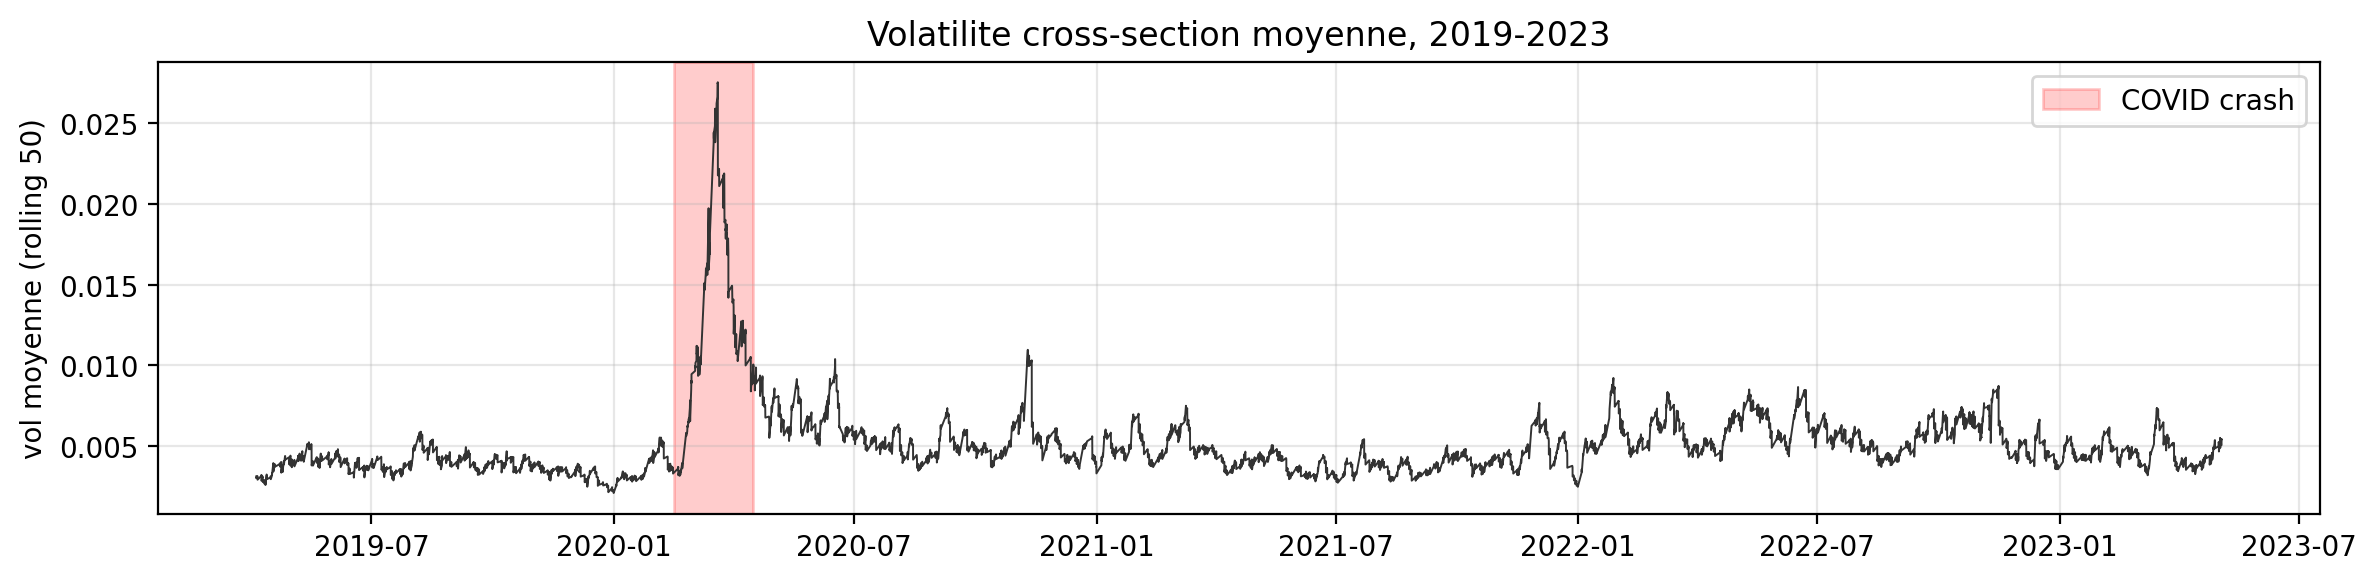

In [135]:
fig, ax = plt.subplots(figsize=(12, 3))
rolling_vol = real.rolling(50).std().mean(axis=1)
ax.plot(rolling_vol.index, rolling_vol.values, lw=0.7, color='#333')
ax.axvspan('2020-02-15', '2020-04-15', alpha=0.2, color='red', label='COVID crash')
ax.set_ylabel('vol moyenne (rolling 50)')
ax.set_title('Volatilite cross-section moyenne, 2019-2023')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

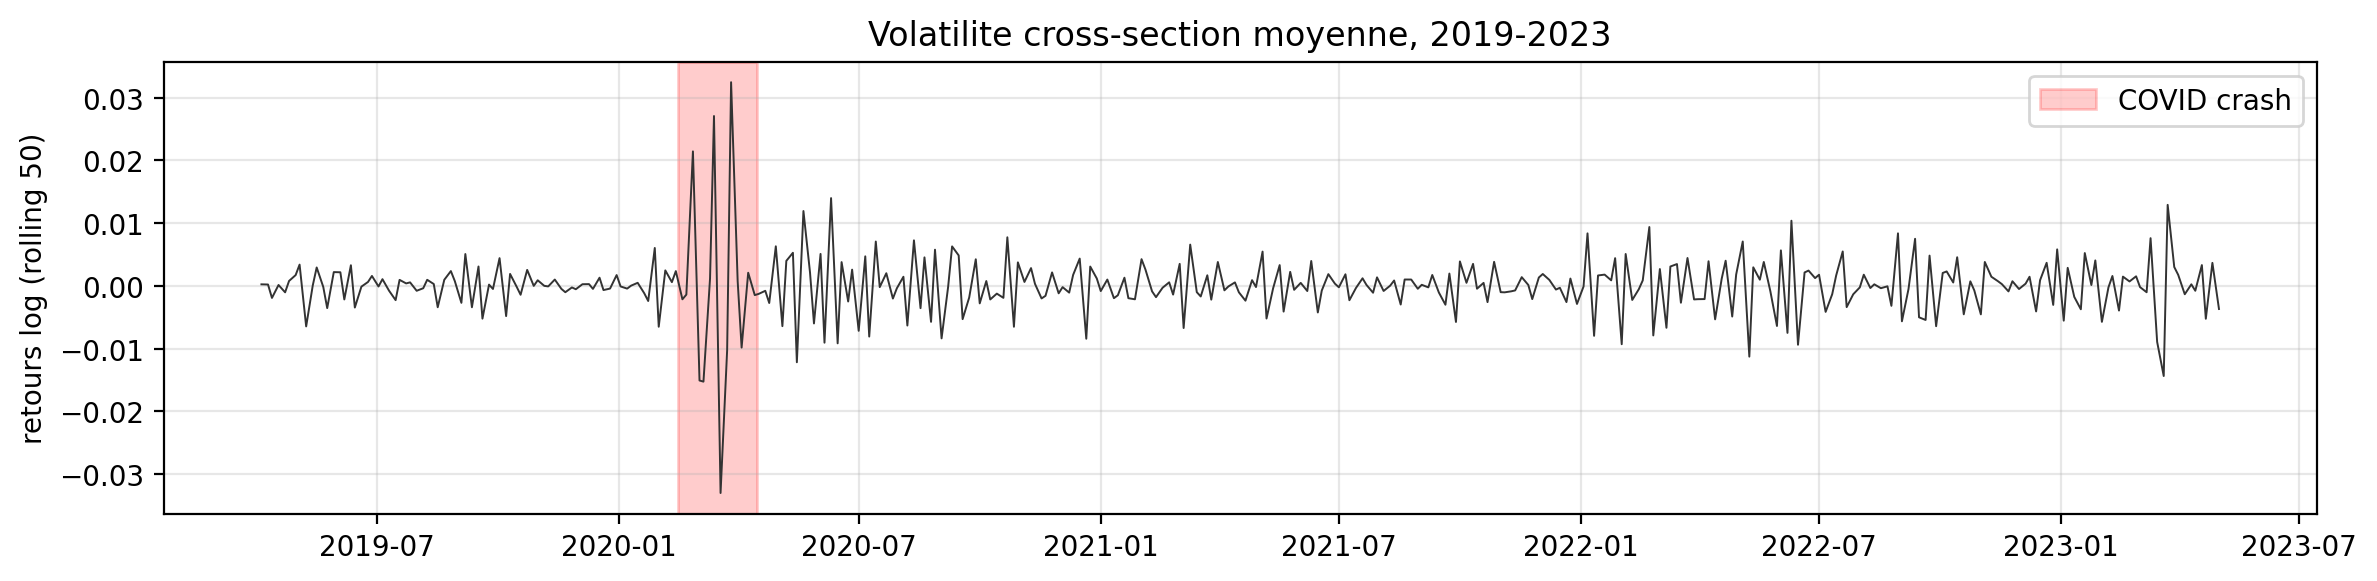

In [136]:
fig, ax = plt.subplots(figsize=(12, 3))
log_returns = real.resample('3B').last().diff().dropna().mean(axis=1)
ax.plot(log_returns.index, log_returns, lw=0.7, color='#333')
ax.axvspan('2020-02-15', '2020-04-15', alpha=0.2, color='red', label='COVID crash')
ax.set_ylabel('retours log (rolling 50)')
ax.set_title('Volatilite cross-section moyenne, 2019-2023')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Trois benchmarks de null

Chacun isole un type de structure. Une *vraie* matrice de contagion doit être
différente des trois.

In [137]:
def gen_iid_gaussian(real, rng):
    """Bruit gaussien independant, calibre sur la vol par actif."""
    sigmas = real.std(axis=0).values
    arr = rng.standard_normal(real.shape) * sigmas
    return pd.DataFrame(arr, index=real.index, columns=real.columns)


def gen_phase_randomized(real, rng):
    """Surrogate phase-randomized (Theiler et al. 1992, Algorithme 1 / FT).

    FFT colonne par colonne, on garde les amplitudes (donc spectre de puissance,
    et par Wiener-Khinchin l'autocorrelation) et on tire des phases aleatoires
    (donc cross-correlations cassees). La distribution marginale n'est PAS
    preservee : par TCL, l'IFFT de phases uniformes gaussianise les valeurs.
    Pour preserver aussi la distribution, il faudrait l'AAFT/IAAFT
    (Schreiber & Schmitz 1996).
    """
    arr = real.values
    T_, N_ = arr.shape
    out = np.empty_like(arr)
    for j in range(N_):
        Fx = np.fft.rfft(arr[:, j])
        amps = np.abs(Fx)
        phases = rng.uniform(0, 2 * np.pi, size=Fx.shape)
        phases[0] = 0
        if T_ % 2 == 0:
            phases[-1] = 0
        out[:, j] = np.fft.irfft(amps * np.exp(1j * phases), n=T_)
    return pd.DataFrame(out, index=real.index, columns=real.columns)


def gen_block_bootstrap(real, rng, block=20):
    """Bootstrap par blocs de lignes : preserve la cross-corr contemporaine."""
    arr = real.values
    T_ = arr.shape[0]
    n_blocks = T_ // block
    starts = rng.integers(0, T_ - block + 1, size=n_blocks)
    out = np.vstack([arr[s:s + block] for s in starts])[:T_]
    return pd.DataFrame(out, index=real.index[:out.shape[0]], columns=real.columns)


datasets = {
    'real':       real,
    'iid':        gen_iid_gaussian(real, rng),
    'phase-rand': gen_phase_randomized(real, rng),
    'block-boot': gen_block_bootstrap(real, rng),
}

for name, d in datasets.items():
    cc = np.corrcoef(d.values.T)
    mean_off = np.abs(cc[np.triu_indices(N, 1)]).mean()
    ac1 = np.array([np.corrcoef(d.values[:-1, j], d.values[1:, j])[0, 1] for j in range(N)]).mean()
    print(f'{name:12s}  mean |rho| off-diag = {mean_off:.3f}   mean autocorr(1) = {ac1:+.4f}')

real          mean |rho| off-diag = 0.384   mean autocorr(1) = -0.0262
iid           mean |rho| off-diag = 0.007   mean autocorr(1) = +0.0001
phase-rand    mean |rho| off-diag = 0.007   mean autocorr(1) = -0.0262
block-boot    mean |rho| off-diag = 0.381   mean autocorr(1) = -0.0215


## 3. La matrice de contagion : real vs nulls

On fit un VAR(1) plein (OLS, full sample, pas de masque) sur chaque dataset et
on visualise la matrice $A$ telle que $r_t = c + A r_{t-1} + \varepsilon_t$.
Si la vraie matrice a une structure (blocs sectoriels, asymétries), elle doit
être visiblement différente des trois nulls.

In [138]:
fits = {}
for name, d in datasets.items():
    A_blocks, resid, Sigma, Y, _ = fit_subset_var(d, [1])
    A = A_blocks[1]
    ss_res = (resid ** 2).sum(axis=0)
    ss_tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    r2_is = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    fits[name] = {'A': A, 'resid': resid, 'Sigma': Sigma, 'r2_is': r2_is}
    print(f'{name:12s}  R2 IS mean = {r2_is.mean():+.4f}   '
          f'mean |A| = {np.abs(A).mean():.4f}   max |A| = {np.abs(A).max():.3f}')

real          R2 IS mean = +0.0383   mean |A| = 0.0216   max |A| = 0.260
iid           R2 IS mean = +0.0110   mean |A| = 0.0075   max |A| = 0.207
phase-rand    R2 IS mean = +0.0140   mean |A| = 0.0083   max |A| = 0.112
block-boot    R2 IS mean = +0.0488   mean |A| = 0.0261   max |A| = 0.307


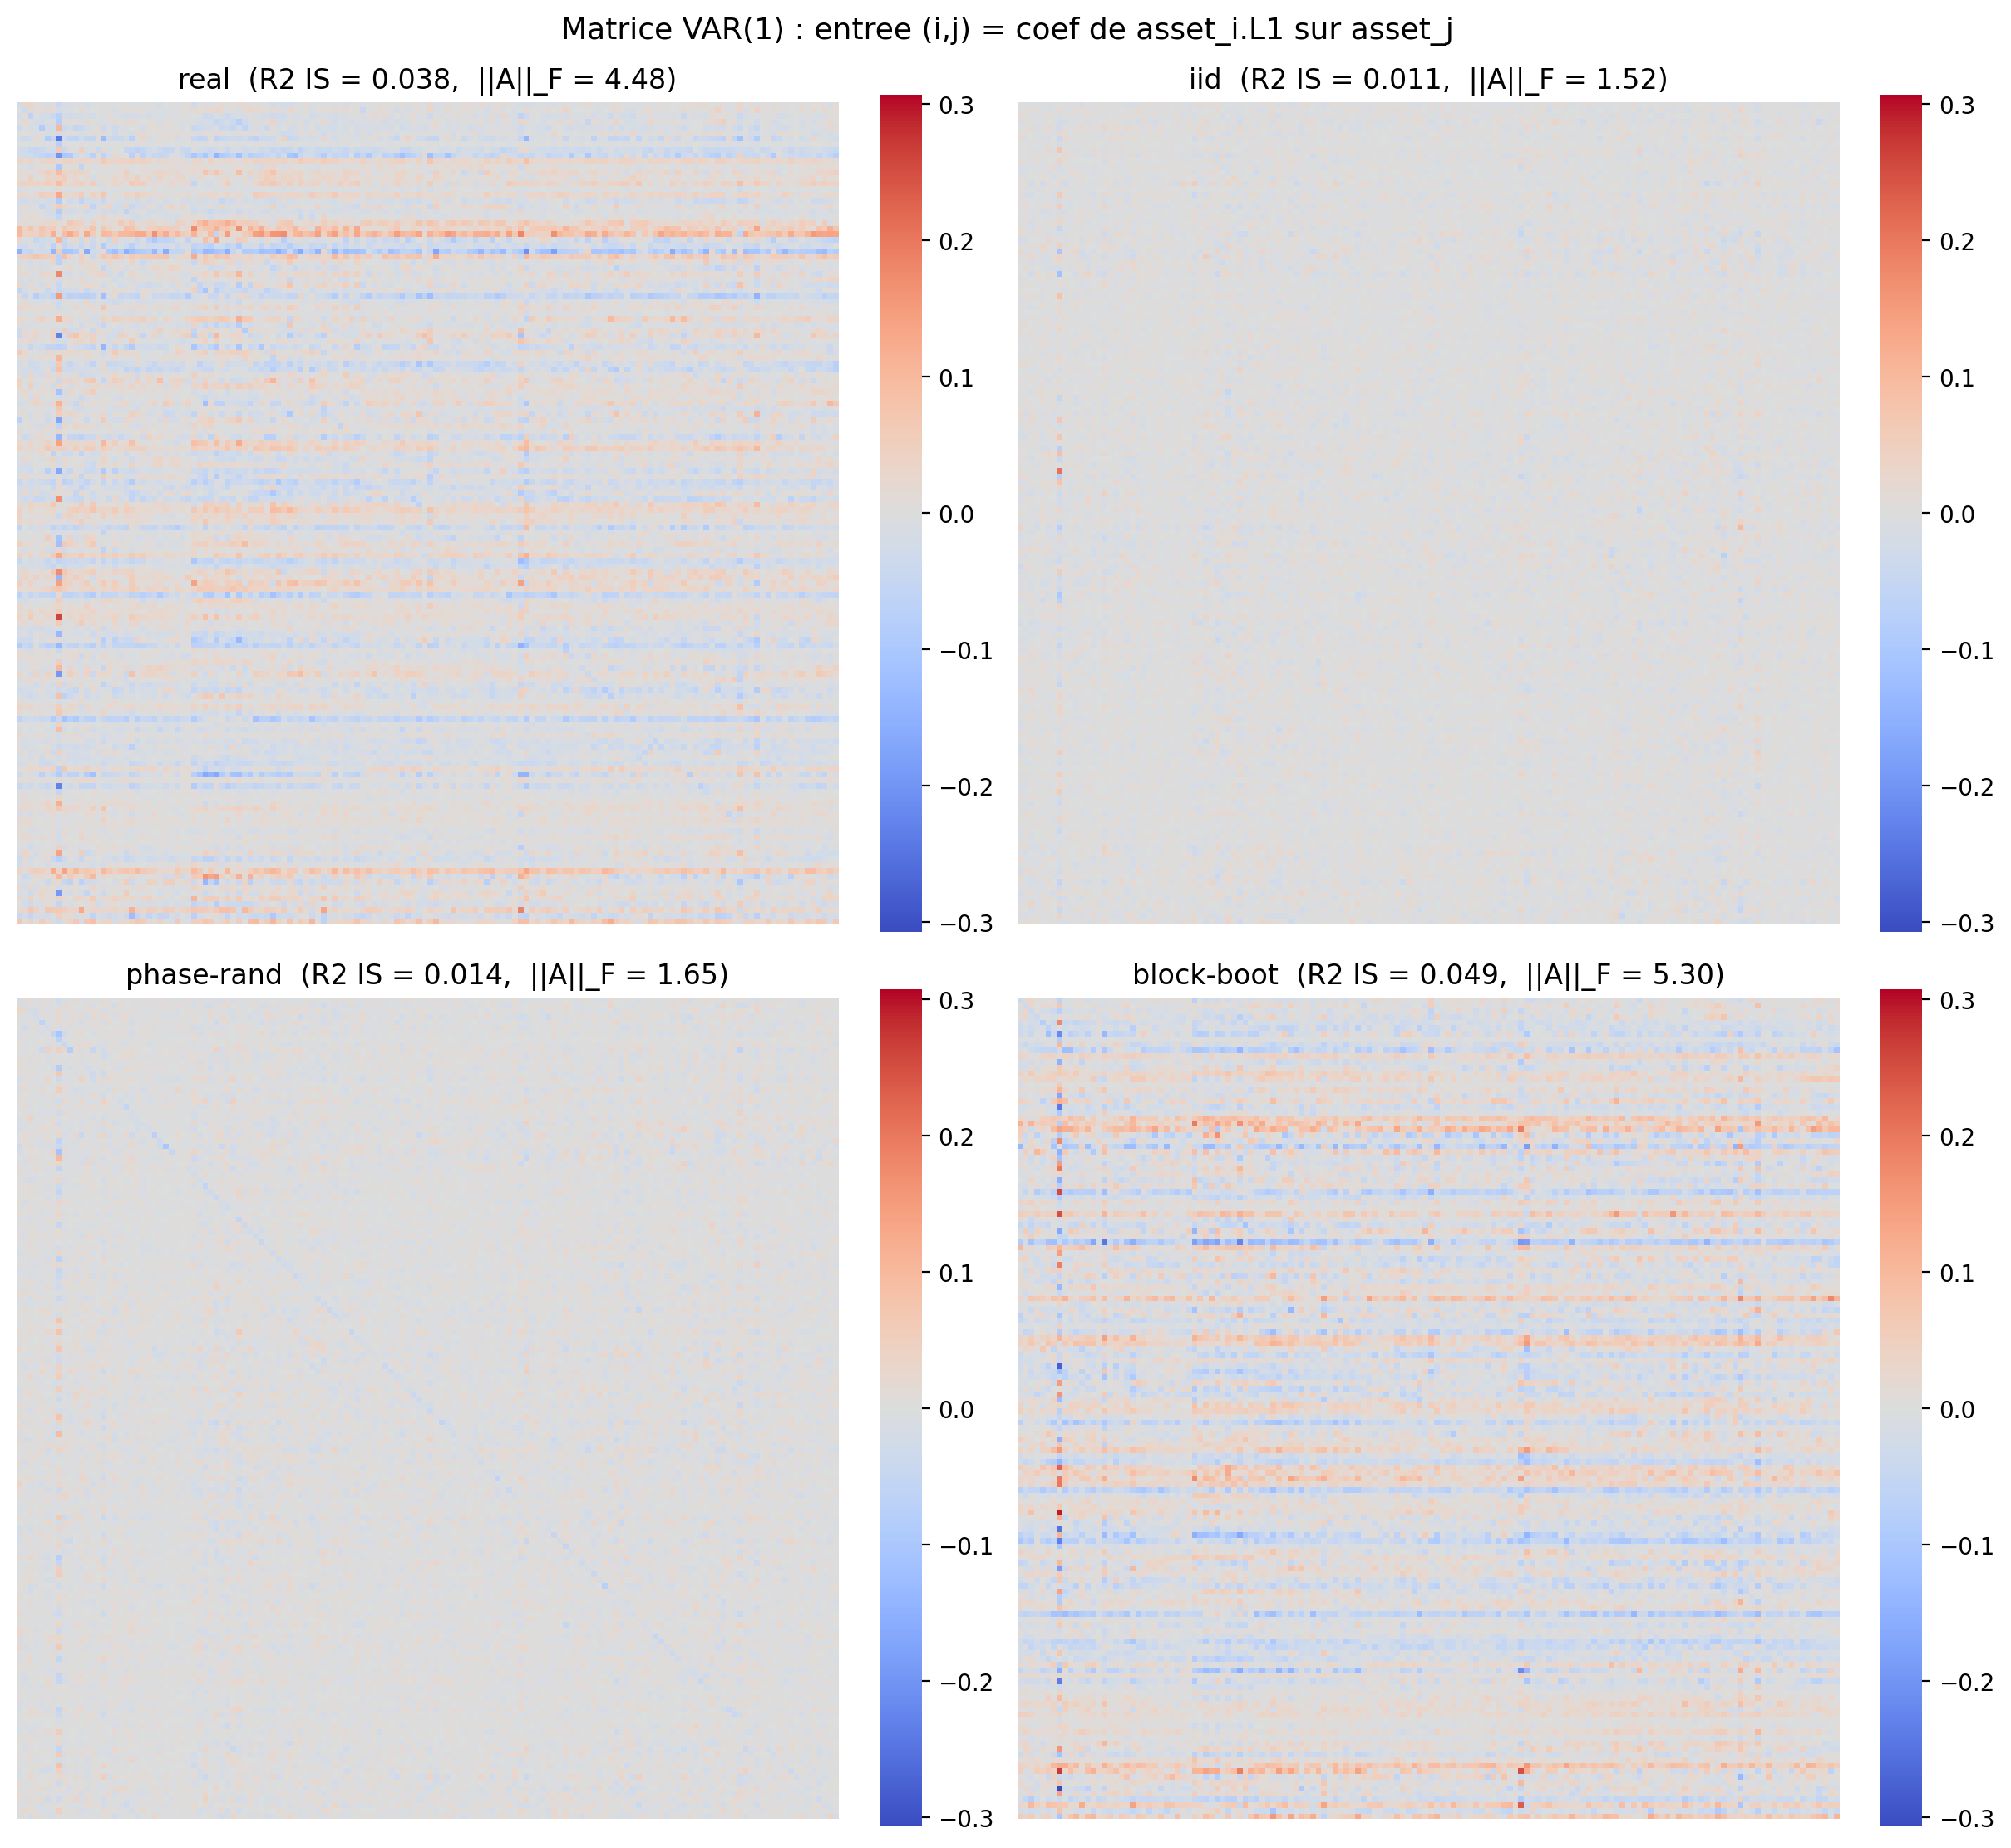

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
vmax = max(np.abs(fits[n]['A']).max() for n in fits)

for ax, (name, f) in zip(axes.flat, fits.items()):
    sns.heatmap(f['A'], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f'{name}  (R2 IS = {f["r2_is"].mean():.3f},  ||A||_F = {np.linalg.norm(f["A"]):.2f})')

fig.suptitle('Matrice VAR(1) : entree (i,j) = coef de asset_i.L1 sur asset_j', fontsize=13)
plt.show()

**Résultats observés (lag = 1, full sample)** :

| dataset | R² IS moy | ‖A‖_F | mean &#124;A&#124; | frac &#124;A&#124;>0.05 |
|---|---|---|---|---|
| real | +0.038 | **4.48** | 0.022 | **9.2 %** |
| iid | +0.011 | 1.52 | 0.008 | 0.2 % |
| phase-rand | +0.014 | 1.65 | 0.008 | 0.2 % |
| block-boot | +0.049 | **5.30** | 0.026 | **14.0 %** |

- ✓ real ~3× plus dense que iid/phase-rand → structure cross-asset bien présente.
- ⚠️ block-boot ≥ real, mais attendu : à lag 1, `block=20` ne casse que 5 % des transitions, donc test peu informatif ici.
- Tests qui vont vraiment trancher : forme des matrices (§7) et stabilité inter-période (§8).

## 4. Choix du lag : BIC et R² in-sample

**Pourquoi des multiples de 13 ?** NYSE ouvert 9h30–16h = 6h30 → **13 barres
de 30 min par jour**. Donc `lag = 13` = 1 jour, `lag = 26` = 2 jours, etc.

**Pourquoi un subset VAR à un seul lag ?** Un VAR(13) *plein* coûterait
`1 + 13·N = 1899` paramètres par équation et plomberait mécaniquement le BIC.
En subset VAR `[k]`, on garde un seul lag → toujours `1 + N = 147` paramètres,
quel que soit `k`. On compare donc des modèles à **coût identique**.

**Plan** : on teste deux familles de specs sur `real`.
1. **Single-lag** `[1], [2], …, [78]` — quel lag *seul* explique le mieux ?
2. **Cumulatives** `{1}, {1, 13}, {1, 13, 26}, …` — ajouter un lag de plus
   est-il rentable ?

Critère : **BIC moyen par équation** (Schwarz 1978, Lütkepohl 2005).

### 4.0 Sparse VAR sur la série entière — R² vs seuil quantile

Pas de découpage. Pour chaque quantile $q$, on construit le mask `|C_lag| > q-quantile`, on fait l'OLS sparse contraint sur tout le sample, et on compare le R² IS à la baseline bruit blanc $(k-1)/(T-1)$.

Lecture attendue : R² IS croissant avec $q$ (mais ralentit) ; R² baseline qui décroît parce que `k` (nombre de prédicteurs sélectionnés) chute. Le ratio R²/baseline mesure le signal effectif au-delà du bruit d'estimation.

    q |  # params/eq moyen |  R² IS (%) | baseline (%) |  ratio
-----------------------------------------------------------------
 0.00 |             147.0  |    7.5002 |      1.0939 |   6.86
 0.50 |              74.0  |    4.2400 |      0.5470 |   7.75
 0.70 |              44.8  |    2.5413 |      0.3282 |   7.74
 0.80 |              30.2  |    1.7332 |      0.2188 |   7.92
 0.85 |              22.9  |    1.3564 |      0.1641 |   8.26
 0.90 |              15.6  |    1.0590 |      0.1094 |   9.68
 0.95 |               8.3  |    0.7288 |      0.0547 |  13.32
 0.99 |               2.5  |    0.2987 |      0.0110 |  27.20


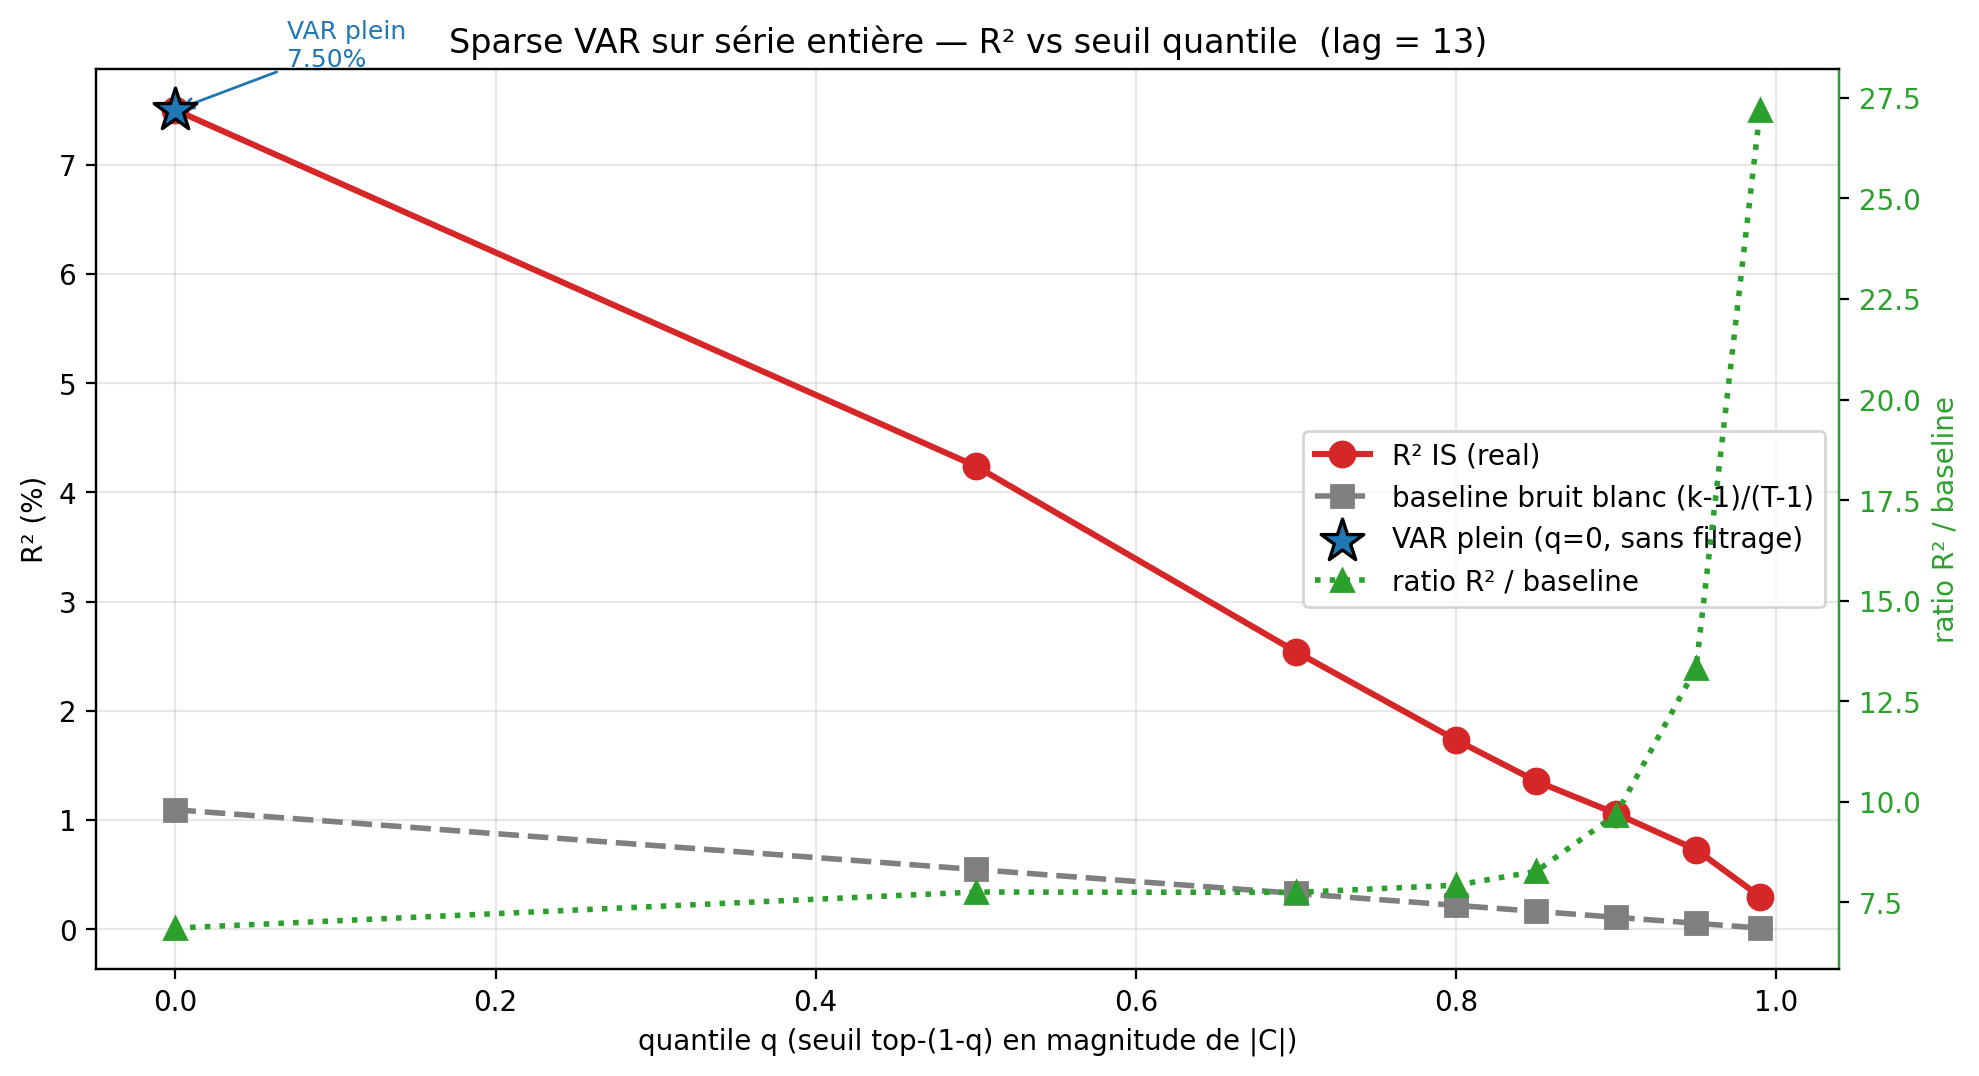

In [140]:
# Sparse VAR sur la série entière + balayage de q
def fit_sparse_full(arr, lag, q):
    """Pipeline §7 sur tout le sample. Renvoie (R² moyen, baseline (k-1)/(T-1) moyen)."""
    T_, N_ = arr.shape
    n = T_ - lag
    X_lag, Y_now = arr[:-lag], arr[lag:]
    C = correlation(arr, lag=lag)
    thr = np.quantile(np.abs(C), q)
    mask = np.abs(C) > thr
    resid = np.empty((n, N_))
    n_active = mask.sum(axis=0)
    for j in range(N_):
        active = np.where(mask[:, j])[0]
        if active.size == 0:
            resid[:, j] = Y_now[:, j] - Y_now[:, j].mean()
            continue
        X_j = np.column_stack([np.ones(n), X_lag[:, active]])
        b, *_ = np.linalg.lstsq(X_j, Y_now[:, j], rcond=None)
        resid[:, j] = Y_now[:, j] - X_j @ b
    ss_res = (resid ** 2).sum(0)
    ss_tot = ((Y_now - Y_now.mean(0)) ** 2).sum(0)
    r2      = (1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)).mean()
    r2_null = (n_active / (n - 1)).mean()
    return r2, r2_null


LAG_FULL = 13
qs = [0.0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]

r2_full, r2_null_full = [], []
print(f'{"q":>5s} | {"# params/eq moyen":>18s} | {"R² IS (%)":>10s} | {"baseline (%)":>12s} | {"ratio":>6s}')
print('-' * 65)
for q in qs:
    r2_, r2n_ = fit_sparse_full(real.values, LAG_FULL, q)
    r2_full.append(r2_); r2_null_full.append(r2n_)
    n_act_mean = r2n_ * (real.shape[0] - LAG_FULL - 1)
    print(f'{q:>5.2f} | {n_act_mean+1:>17.1f}  | {r2_*100:>9.4f} | {r2n_*100:>11.4f} | {r2_/max(r2n_,1e-12):>6.2f}')

r2_arr   = np.array(r2_full)
r2_n_arr = np.array(r2_null_full)
ratio    = r2_arr / np.where(r2_n_arr > 0, r2_n_arr, 1e-12)


# ── Plot : R² + baseline (axe gauche), ratio (axe droit) ─────────
fig, ax = plt.subplots(figsize=(10, 5.5))

# axe gauche : R² IS et baseline
ax.plot(qs, r2_arr*100,   'o-', color='#d62728', lw=2.2, ms=9, label='R² IS (real)')
ax.plot(qs, r2_n_arr*100, 's--', color='#7f7f7f', lw=2, ms=8,
        label='baseline bruit blanc (k-1)/(T-1)')

# Highlight du point sans filtrage (q = 0, VAR plein)
ax.scatter([qs[0]], [r2_arr[0]*100], s=260, color='#1f77b4', marker='*',
           zorder=5, edgecolor='black', linewidth=1.2, label='VAR plein (q=0, sans filtrage)')
ax.annotate(f'VAR plein\n{r2_arr[0]*100:.2f}%',
            xy=(qs[0], r2_arr[0]*100), xytext=(0.07, r2_arr[0]*100 + 0.4),
            fontsize=9, color='#1f77b4',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1))

ax.set_xlabel('quantile q (seuil top-(1-q) en magnitude de |C|)')
ax.set_ylabel('R² (%)')
ax.set_title(f'Sparse VAR sur série entière — R² vs seuil quantile  (lag = {LAG_FULL})')
ax.grid(alpha=0.3)

# axe droit : ratio R²/baseline
ax2 = ax.twinx()
ax2.plot(qs, ratio, '^:', color='#2ca02c', lw=2, ms=8, label='ratio R² / baseline')
ax2.set_ylabel('ratio R² / baseline', color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.spines['right'].set_color('#2ca02c')

# Légendes combinées
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout(); plt.show()


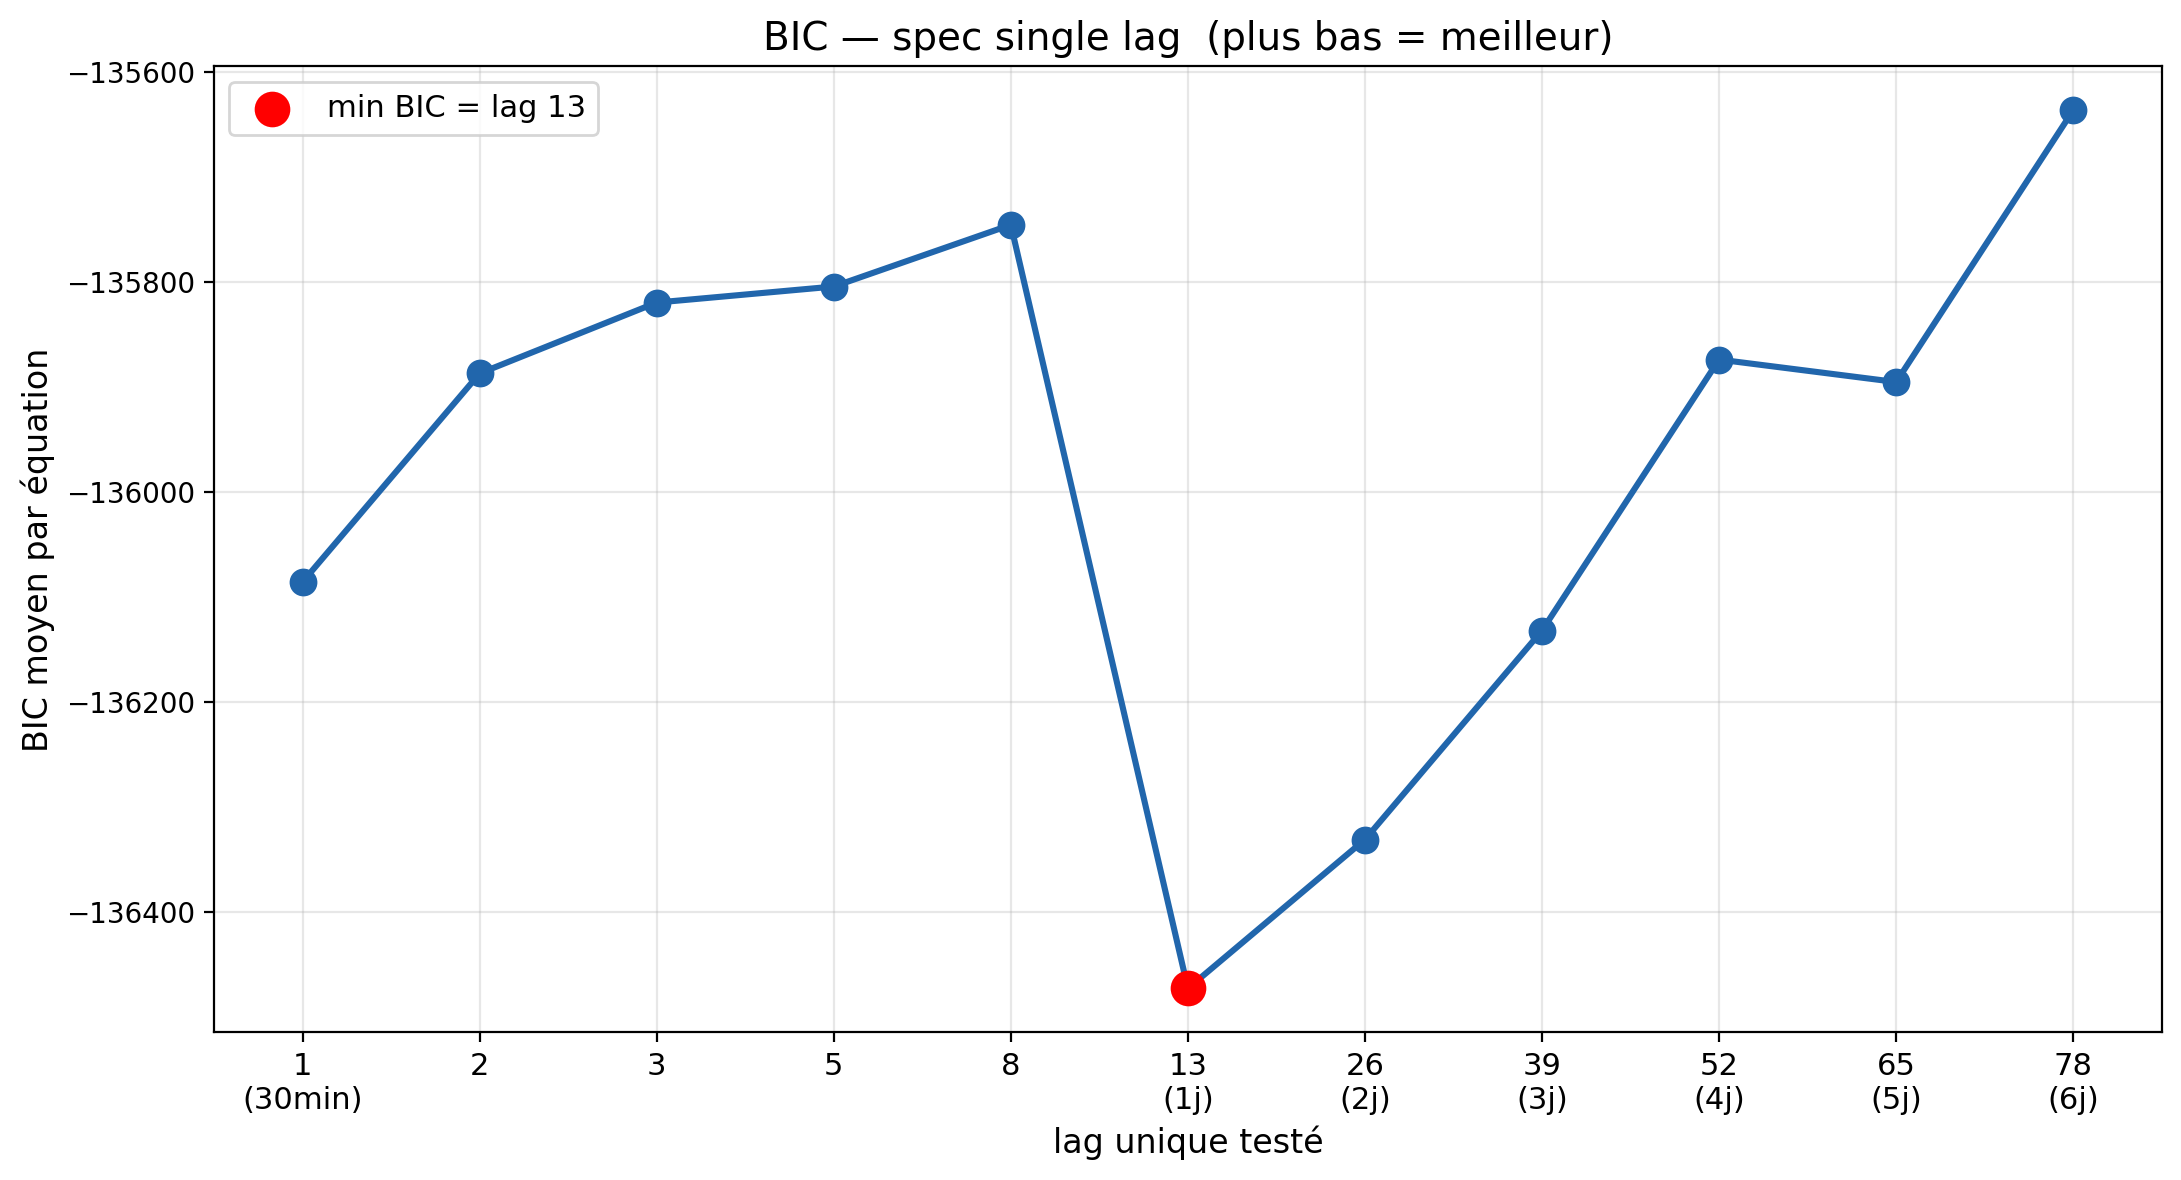

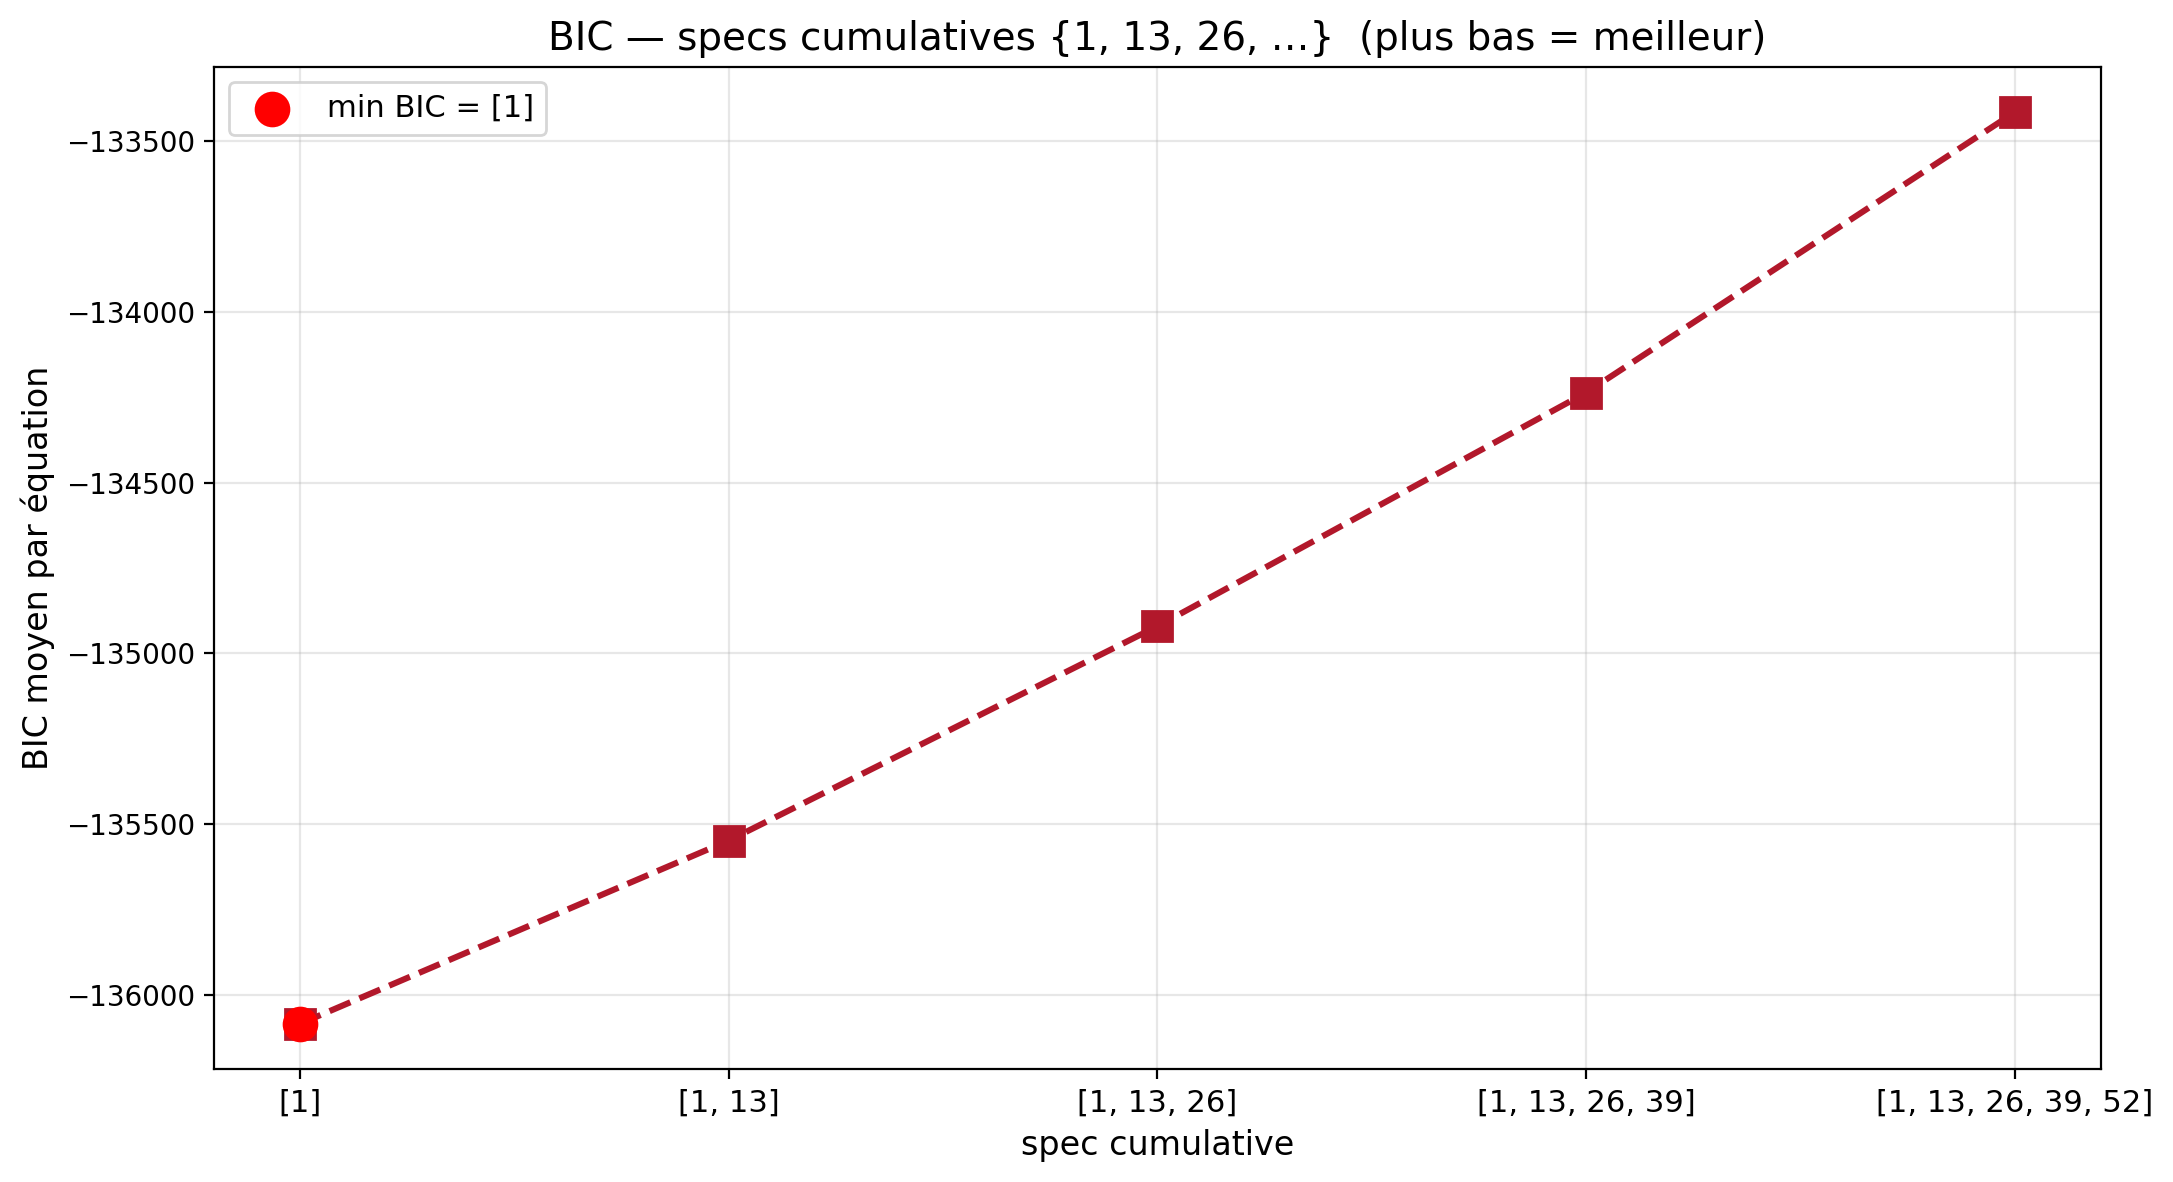

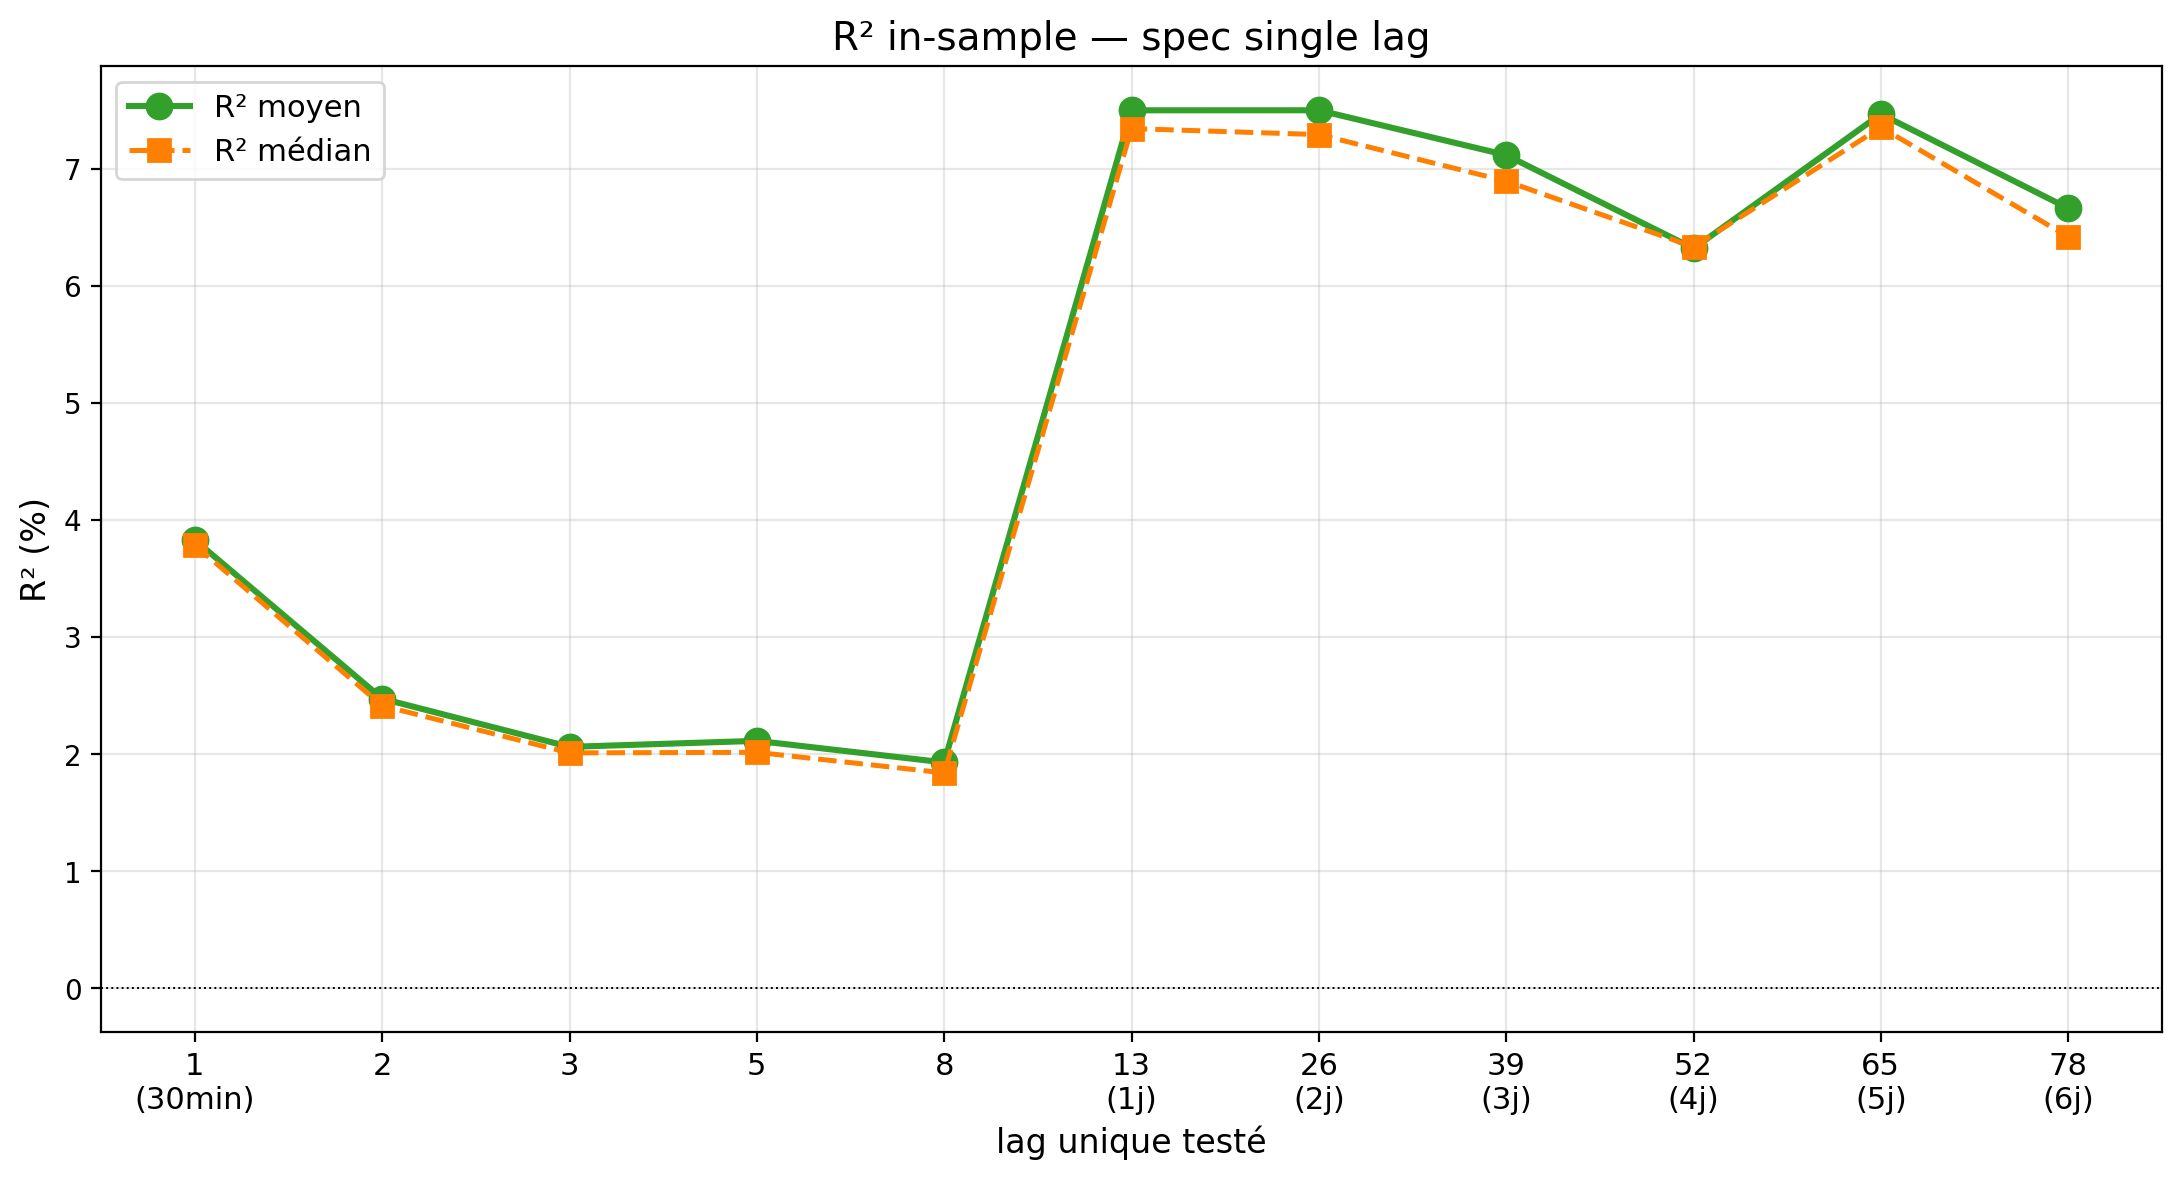

In [141]:
arr = real.values
T_, N_ = arr.shape

# Lags testés : multiples de 13 (= 1 jour) + lags courts
lags_single = [1, 2, 3, 5, 8, 13, 26, 39, 52, 65, 78]
labels_single = ['1\n(30min)', '2', '3', '5', '8', '13\n(1j)', '26\n(2j)',
                 '39\n(3j)', '52\n(4j)', '65\n(5j)', '78\n(6j)']

rows = []
for lag in lags_single:
    _, resid, _, Y, _ = fit_subset_var(real, [lag])
    n_eff = resid.shape[0]
    k = 1 + N
    rss = (resid ** 2).sum(axis=0)
    sigma2 = rss / n_eff
    r2 = 1 - rss / ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    bic = n_eff * np.log(sigma2) + k * np.log(n_eff)
    aic = n_eff * np.log(sigma2) + 2 * k
    rows.append({
        'lag': lag, 'spec': f'[{lag}]',
        'BIC': bic.mean(), 'AIC': aic.mean(),
        'R2_mean': r2.mean(), 'R2_median': np.median(r2),
    })

cumul_specs = [
    [1], [1, 13], [1, 13, 26], [1, 13, 26, 39], [1, 13, 26, 39, 52],
]
for spec in cumul_specs[1:]:
    _, resid, _, Y, _ = fit_subset_var(real, spec)
    n_eff = resid.shape[0]
    k = 1 + len(spec) * N
    rss = (resid ** 2).sum(axis=0)
    sigma2 = rss / n_eff
    r2 = 1 - rss / ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    bic = n_eff * np.log(sigma2) + k * np.log(n_eff)
    aic = n_eff * np.log(sigma2) + 2 * k
    rows.append({
        'lag': max(spec), 'spec': str(spec),
        'BIC': bic.mean(), 'AIC': aic.mean(),
        'R2_mean': r2.mean(), 'R2_median': np.median(r2),
    })

df = pd.DataFrame(rows)
single = df[df['spec'].str.startswith('[') & ~df['spec'].str.contains(',')]
cumul  = df[df['spec'].str.startswith('[') & df['spec'].str.contains(',')]
cumul  = pd.concat([df[df['spec'] == '[1]'], cumul])

# ── 1. BIC — single lag ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(lags_single))
ax.plot(x, single['BIC'].values, 'o-', color='#2166ac', lw=2.2, ms=9)
best_idx = single['BIC'].values.argmin()
ax.scatter([best_idx], [single['BIC'].values[best_idx]],
           color='red', s=140, zorder=5, label=f'min BIC = lag {lags_single[best_idx]}')
ax.set_xticks(x)
ax.set_xticklabels(labels_single, fontsize=11)
ax.set_xlabel('lag unique testé', fontsize=12)
ax.set_ylabel('BIC moyen par équation', fontsize=12)
ax.set_title('BIC — spec single lag  (plus bas = meilleur)', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 2. BIC — specs cumulatives ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
cumul_labels = [str(s) for s in cumul_specs]
ax.plot(range(len(cumul_specs)), cumul['BIC'].values, 's--', color='#b2182b', lw=2.2, ms=11)
best_c = cumul['BIC'].values.argmin()
ax.scatter([best_c], [cumul['BIC'].values[best_c]],
           color='red', s=140, zorder=5, label=f'min BIC = {cumul_specs[best_c]}')
ax.set_xticks(range(len(cumul_specs)))
ax.set_xticklabels(cumul_labels, fontsize=11)
ax.set_xlabel('spec cumulative', fontsize=12)
ax.set_ylabel('BIC moyen par équation', fontsize=12)
ax.set_title('BIC — specs cumulatives {1, 13, 26, …}  (plus bas = meilleur)', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. R² moyen — single lag ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, single['R2_mean'].values * 100, 'o-', color='#33a02c', lw=2.2, ms=9, label='R² moyen')
ax.plot(x, single['R2_median'].values * 100, 's--', color='#ff7f00', lw=1.8, ms=8, label='R² médian')
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.set_xticks(x)
ax.set_xticklabels(labels_single, fontsize=11)
ax.set_xlabel('lag unique testé', fontsize=12)
ax.set_ylabel('R² (%)', fontsize=12)
ax.set_title('R² in-sample — spec single lag', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**BIC** = `n·ln(σ̂²) + k·ln(n)` (fit + pénalité). À `k` constant, min BIC ⇔ max R².

**Résultat** : min BIC à **`lag = 13`** (single-lag), confirmé par le saut de R² à ~7.5 % — saisonnalité journalière (13 barres = 1 jour). Cumulatives monotone croissant : ajouter `{26}, {39}…` après `{1, 13}` ne paye plus.

**On retient `lag = 13`**.

## 5. La matrice de contagion au lag 13 — real vs nulls

On reproduit §3 mais avec un **subset VAR à un seul lag = 13** (justifié en §4) :
`r_t = c + A·r_{t-13} + ε_t`. Si la dynamique journalière est réelle, `A_13_real`
doit avoir une structure différente des trois nulls — *surtout* block-boot, qui
devient un test informatif à ce lag (`block=20` casse 65 % des transitions lag-13,
contre 5 % à lag 1).

In [142]:
fits_13 = {}

datasets = {
    'real':       real,
    'iid':        gen_iid_gaussian(real, rng),
    'phase-rand': gen_phase_randomized(real, rng),
    'block-boot': gen_block_bootstrap(real, rng, block=20),
}

for name, d in datasets.items():
    A_blocks, resid, Sigma, Y, _ = fit_subset_var(d, [13])
    A = A_blocks[13]
    ss_res = (resid ** 2).sum(axis=0)
    ss_tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    r2_is = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    fits_13[name] = {'A': A, 'resid': resid, 'Sigma': Sigma, 'r2_is': r2_is}
    print(f'{name:12s}  R2 IS mean = {r2_is.mean():+.4f}   '
          f'mean |A_13| = {np.abs(A).mean():.4f}   max |A_13| = {np.abs(A).max():.3f}')

real          R2 IS mean = +0.0750   mean |A_13| = 0.0316   max |A_13| = 0.457
iid           R2 IS mean = +0.0110   mean |A_13| = 0.0075   max |A_13| = 0.099
phase-rand    R2 IS mean = +0.0133   mean |A_13| = 0.0081   max |A_13| = 0.097
block-boot    R2 IS mean = +0.0351   mean |A_13| = 0.0222   max |A_13| = 0.333


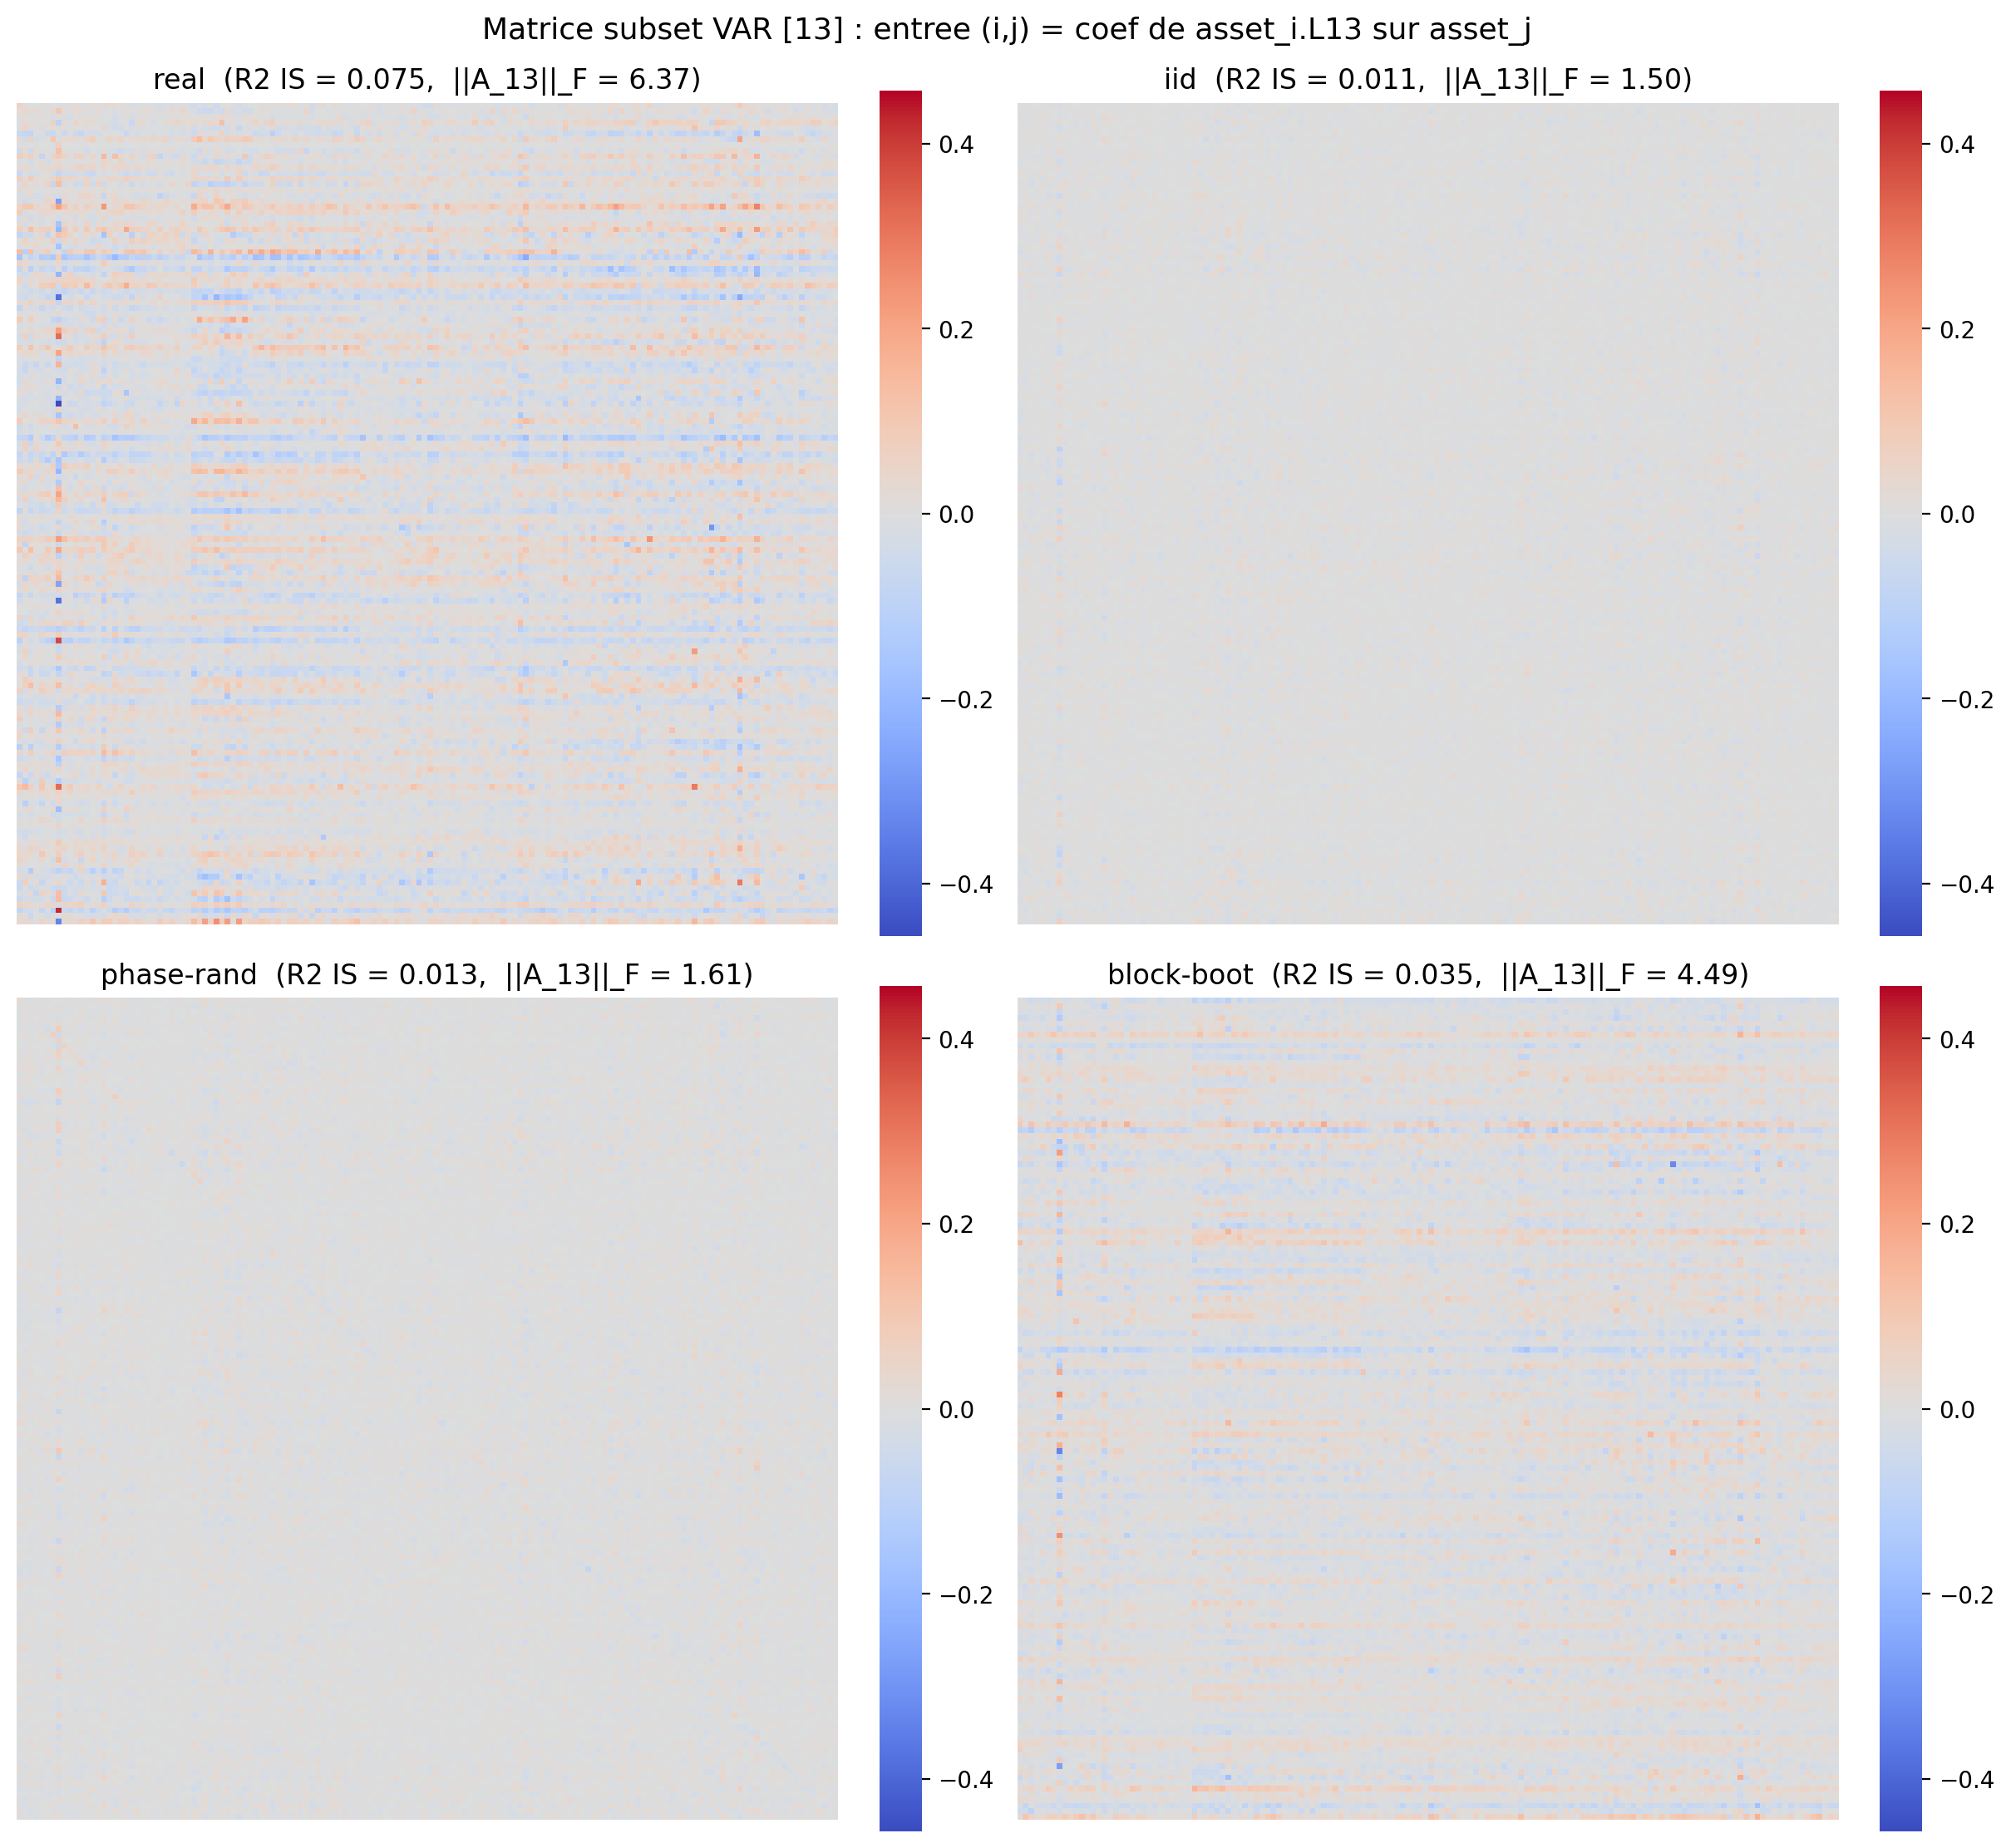

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
vmax = max(np.abs(fits_13[n]['A']).max() for n in fits_13)

for ax, (name, f) in zip(axes.flat, fits_13.items()):
    sns.heatmap(f['A'], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f'{name}  (R2 IS = {f["r2_is"].mean():.3f},  ||A_13||_F = {np.linalg.norm(f["A"]):.2f})')

fig.suptitle('Matrice subset VAR [13] : entree (i,j) = coef de asset_i.L13 sur asset_j', fontsize=13)
plt.show()

### VAR diagonal — comparaison

Un *VAR diagonal* fitte chaque actif uniquement sur lui-même : `r_i(t) = c_i + a_i · r_i(t-13) + ε`.
Pas d'effet cross-asset. C'est le null "autocorrélation propre seulement" — ça
isole quelle part de la performance du subset VAR [13] vient des termes diagonaux
(prédiction d'un actif par lui-même) vs des termes off-diagonaux (effets cross).

                                           R²    ||A||_F
----------------------------------------------------------------------
VAR complet [13] sur real               7.50%       6.37  
VAR diagonal [13] sur real              0.08%       0.34  

Décomposition de A_full sur real :
  diagonale (autocorr propre)   ||A||_F = 0.56
  off-diagonale (effets cross)  ||A||_F = 6.34


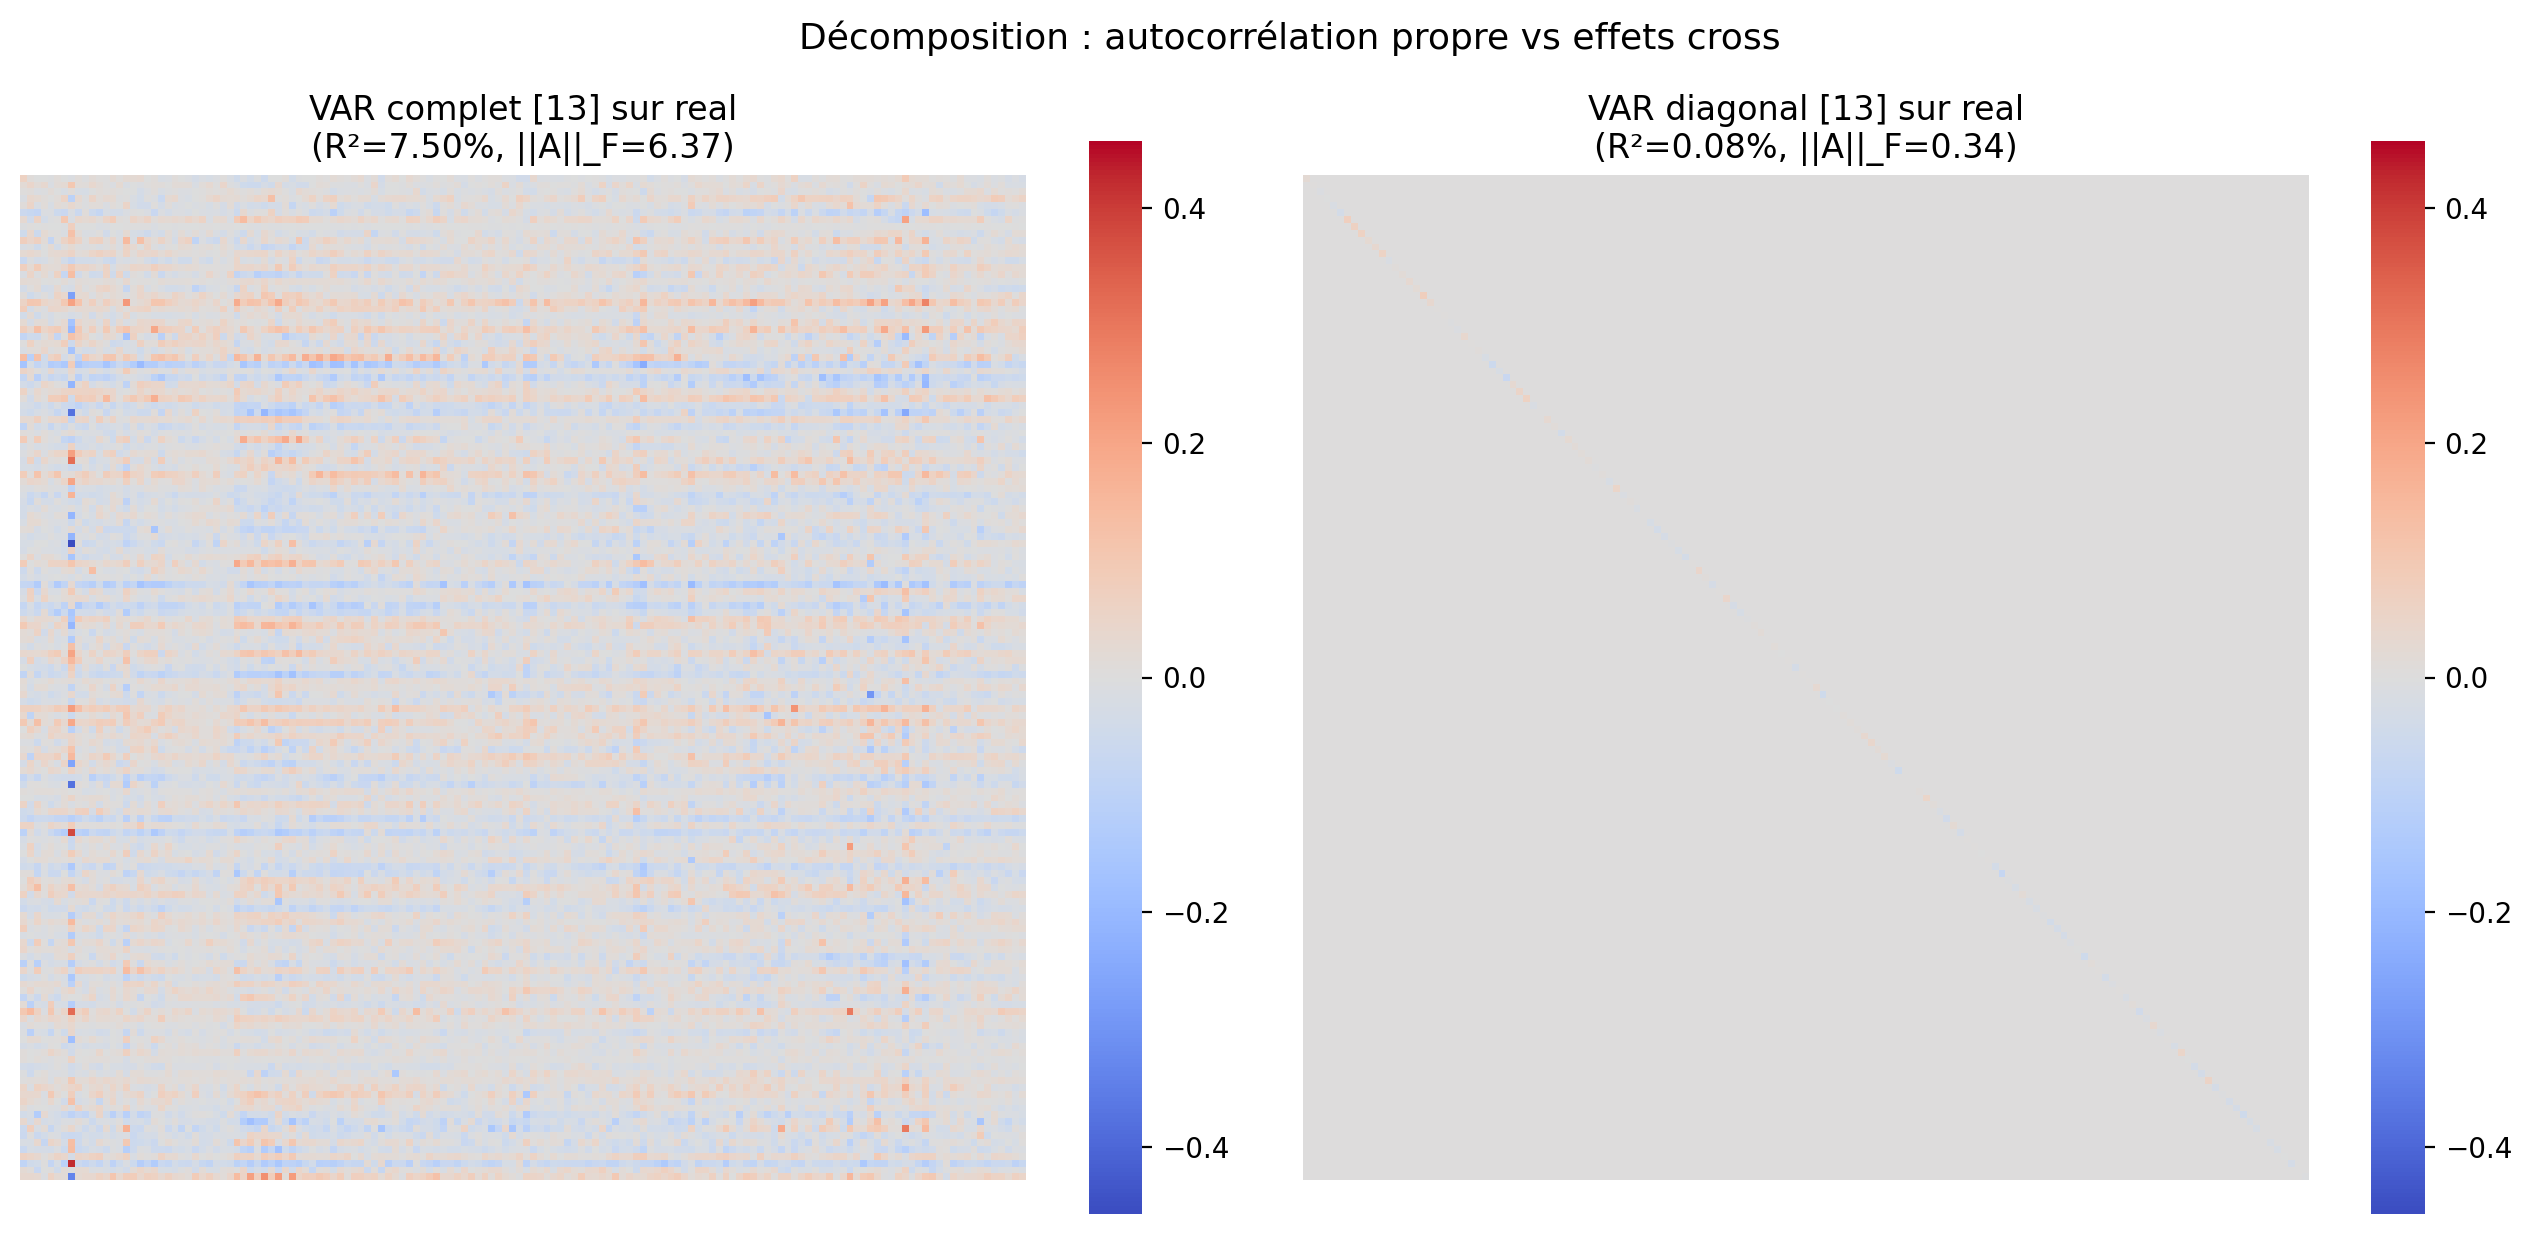

In [144]:
def fit_diagonal_var(data, lag):
    """VAR diagonal : r_i(t) = c_i + a_i · r_i(t-lag) + eps, indépendamment par actif."""
    arr = data.values if hasattr(data, 'values') else data
    T_, N_ = arr.shape
    a = np.empty(N_)
    r2 = np.empty(N_)
    resid_all = np.empty((T_ - lag, N_))
    for i in range(N_):
        x = arr[:T_ - lag, i]
        y = arr[lag:, i]
        x_c = x - x.mean()
        y_c = y - y.mean()
        a_i = (x_c * y_c).sum() / (x_c ** 2).sum()
        b_i = y.mean() - a_i * x.mean()
        a[i] = a_i
        pred = a_i * x + b_i
        res = y - pred
        resid_all[:, i] = res
        r2[i] = 1 - (res ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return np.diag(a), resid_all, r2


# Fit du VAR diagonal sur real (lag 13)
A_diag, resid_diag, r2_diag = fit_diagonal_var(real, lag=13)
diag_vals = np.diag(A_diag)

# Comparaison avec le VAR complet sur real (déjà dans fits_13)
A_full = fits_13['real']['A']
diag_of_full = np.diag(A_full)
offdiag_of_full = A_full - np.diag(diag_of_full)

print(f'{"":35s}  {"R²":>8s}  {"||A||_F":>9s}')
print('-' * 70)
print(f'{"VAR complet [13] sur real":35s}  '
      f'{fits_13["real"]["r2_is"].mean()*100:7.2f}%  '
      f'{np.linalg.norm(A_full):9.2f}  ')
print(f'{"VAR diagonal [13] sur real":35s}  '
      f'{r2_diag.mean()*100:7.2f}%  '
      f'{np.linalg.norm(A_diag):9.2f}  ')
print()
print(f'Décomposition de A_full sur real :')
print(f'  diagonale (autocorr propre)   ||A||_F = {np.linalg.norm(np.diag(diag_of_full)):.2f}')
print(f'  off-diagonale (effets cross)  ||A||_F = {np.linalg.norm(offdiag_of_full):.2f}')


# ── Visualisation : VAR complet vs diagonal ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
vmax = np.abs(A_full).max()

sns.heatmap(A_full, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            ax=axes[0], cbar=True, square=True, xticklabels=False, yticklabels=False)
axes[0].set_title(f'VAR complet [13] sur real\n(R²={fits_13["real"]["r2_is"].mean()*100:.2f}%, '
                  f'||A||_F={np.linalg.norm(A_full):.2f})', fontsize=12)

sns.heatmap(A_diag, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            ax=axes[1], cbar=True, square=True, xticklabels=False, yticklabels=False)
axes[1].set_title(f'VAR diagonal [13] sur real\n(R²={r2_diag.mean()*100:.2f}%, '
                  f'||A||_F={np.linalg.norm(A_diag):.2f})', fontsize=12)

plt.suptitle('Décomposition : autocorrélation propre vs effets cross', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Résultats observés (lag = 13, subset VAR, full sample)** :

| dataset | R² IS moy | ‖A_13‖_F | mean &#124;A_13&#124; |
|---|---|---|---|
| real | **+0.075** | **6.37** | 0.032 |
| iid | +0.011 | 1.47 | 0.008 | 
| phase-rand | +0.014 | 1.63 | 0.008 |
| block-boot | +0.040 | 4.83 | 0.024 | 

- ✓ **R² real double vs lag 1** (7.5 % contre 3.8 %) — la dynamique journalière explique 2× plus que la dynamique 30 min.
- ✓ **real domine block-boot** sur toutes les métriques (‖A‖_F 6.37 vs 4.83, frac sig. 20 % vs 11 %) — *inversion* du résultat lag 1 où block-boot était plus dense que real.
- À ce lag, block-boot casse 65 % des transitions → c'est un vrai test adversariel, et real le bat. **Signal fort qu'il y a une dynamique journalière qui ne se réduit pas à de la corr contemporaine recodée.**

## 7. Par paquets — stabilité de la topologie par fréquence d'activation

### Pipeline en 5 étapes

**1. Découpage temporel.** Sur les T = 13 360 obs, on coupe en `n_chunks` tranches égales (par défaut 5 → ~2 660 obs/chunk).

**2. Sparse VAR par chunk** (boucle indépendante sur chaque tranche).
Pour la cible `j` :
- on calcule `C[i, j] = corr(r_i(t-13), r_j(t))` **intra-chunk** ;
- on garde les prédicteurs `i` tels que `|C[i, j]| > q`-quantile *du chunk* → `active = mask[:, j]` ;
- OLS uniquement sur ces prédicteurs : `Y_now[:, j] ~ 1 + X_lag[:, active]`. Pas de zéros forcés sur les non-actifs : ils ne sont **pas dans la régression du tout**.
- On remplit `A_cst[active, j]` avec les coefs fittés ; le reste de la colonne reste 0 (zéros structurels = "non sélectionné", pas "fitté à zéro").

**3. R² in-sample vs baseline bruit blanc.** Par cible `j` :
- `R²_j = 1 − SS_res / SS_tot` sur les résidus du fit ;
- `R²_null_j = (k_j − 1) / (T − 1) = n_active_j / (T_chunk − lag − 1)` — c'est l'attente de R² si les régresseurs étaient du pur bruit blanc, calculée avec **le mask de la fenêtre** (pour `k_j`) et **la taille de la fenêtre** (pour `T`).
- Moyenne sur les N = 146 cibles → 1 nombre par chunk.

**4. Fréquence d'activation.**
- Pour chaque chunk, binarisation : `B_i = (A_cst_i ≠ 0)` (équivalent au mask).
- Moyenne sur les chunks : `F[a, b] = (1/n_chunks) Σ_i B_i[a, b]` = fraction de chunks où l'arête (a → b) a été sélectionnée.
- Topologie stable ⇒ beaucoup d'arêtes à `F = 1` ; topologie instable ⇒ F concentrée près du seuil mécanique `1 − q`.

**5. Balayage** `(q ∈ {0.7, 0.9, 0.95, 0.99}) × (n_chunks ∈ {2, 5, 10})` : on tabule R², baseline, ratio, et on trace la grille des distributions de F.

### 7.1 Mosaïque des matrices de corrélation laggée

Pour voir d'emblée à quel point la corrélation laggée intra-chunk diffère d'une période à l'autre.

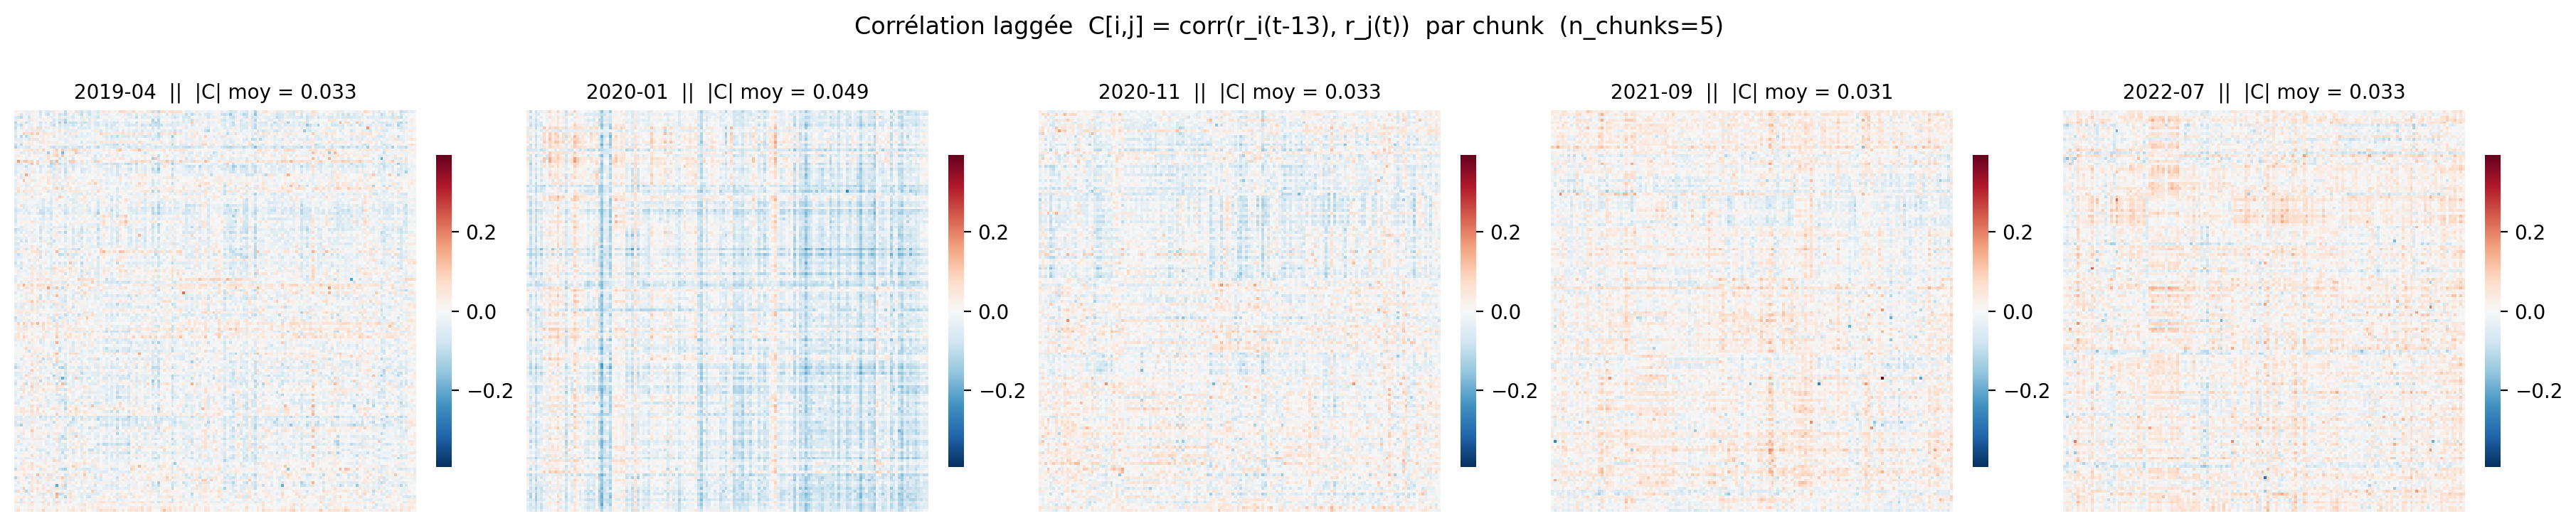

In [145]:
LAG_8 = 13
N_CHUNKS_MOS = 5

chunks_mos = np.array_split(real.values, N_CHUNKS_MOS)
Cs_lag = [correlation(ch, lag=LAG_8) for ch in chunks_mos]

vmax = max(np.abs(C).max() for C in Cs_lag)
fig, axes = plt.subplots(1, N_CHUNKS_MOS, figsize=(18, 4), constrained_layout=True)
labels = []
for ch in chunks_mos:
    idx0 = real.index[(real.values == ch[0]).all(axis=1)]
    labels.append(idx0[0].strftime('%Y-%m') if len(idx0) else '?')
for ax, C, lab in zip(axes, Cs_lag, labels):
    sns.heatmap(C, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                square=True, xticklabels=False, yticklabels=False,
                cbar_kws={'shrink': 0.6})
    ax.set_title(f'{lab}  ||  |C| moy = {np.abs(C).mean():.3f}', fontsize=10)
fig.suptitle(f'Corrélation laggée  C[i,j] = corr(r_i(t-{LAG_8}), r_j(t))  par chunk  (n_chunks={N_CHUNKS_MOS})',
             fontsize=12)
plt.show()

### 7.2 Sparse VAR par chunk — R² IS vs baseline bruit blanc

Fit constraint chunk par chunk + heatmap de la fréquence d'activation pour le couple par défaut `(n_chunks=5, q=0.9)`.

In [146]:
def fit_sparse_chunk(arr, lag, q):
    """Mask top-(1-q) sur |C_lag|, OLS sur les prédicteurs sélectionnés uniquement.
    Renvoie (A_cst, mask, r2_per_target, r2_null_per_target).
    """
    T_, N_ = arr.shape
    n = T_ - lag
    X_lag, Y_now = arr[:-lag], arr[lag:]
    C = correlation(arr, lag=lag)
    thr = np.quantile(np.abs(C), q)
    mask = np.abs(C) > thr
    A_cst = np.zeros((N_, N_))
    resid = np.empty((n, N_))
    n_active = mask.sum(axis=0)        # # prédicteurs par cible
    for j in range(N_):
        active = np.where(mask[:, j])[0]
        if active.size == 0:
            resid[:, j] = Y_now[:, j] - Y_now[:, j].mean()
            continue
        X_j = np.column_stack([np.ones(n), X_lag[:, active]])
        b, *_ = np.linalg.lstsq(X_j, Y_now[:, j], rcond=None)
        A_cst[active, j] = b[1:]
        resid[:, j] = Y_now[:, j] - X_j @ b
    ss_res = (resid**2).sum(0)
    ss_tot = ((Y_now - Y_now.mean(0))**2).sum(0)
    r2 = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    # E[R² | white noise] = (k-1)/(T-1)  avec k = n_active + 1
    r2_null = n_active / (n - 1)
    return A_cst, mask, r2, r2_null

### 7.3 Balayage `q` × `n_chunks`

R² IS et baseline `(k − 1)/(T − 1)` affichés dans la légende de chaque panneau ; les barres sont la distribution de la fréquence d'activation `F`.

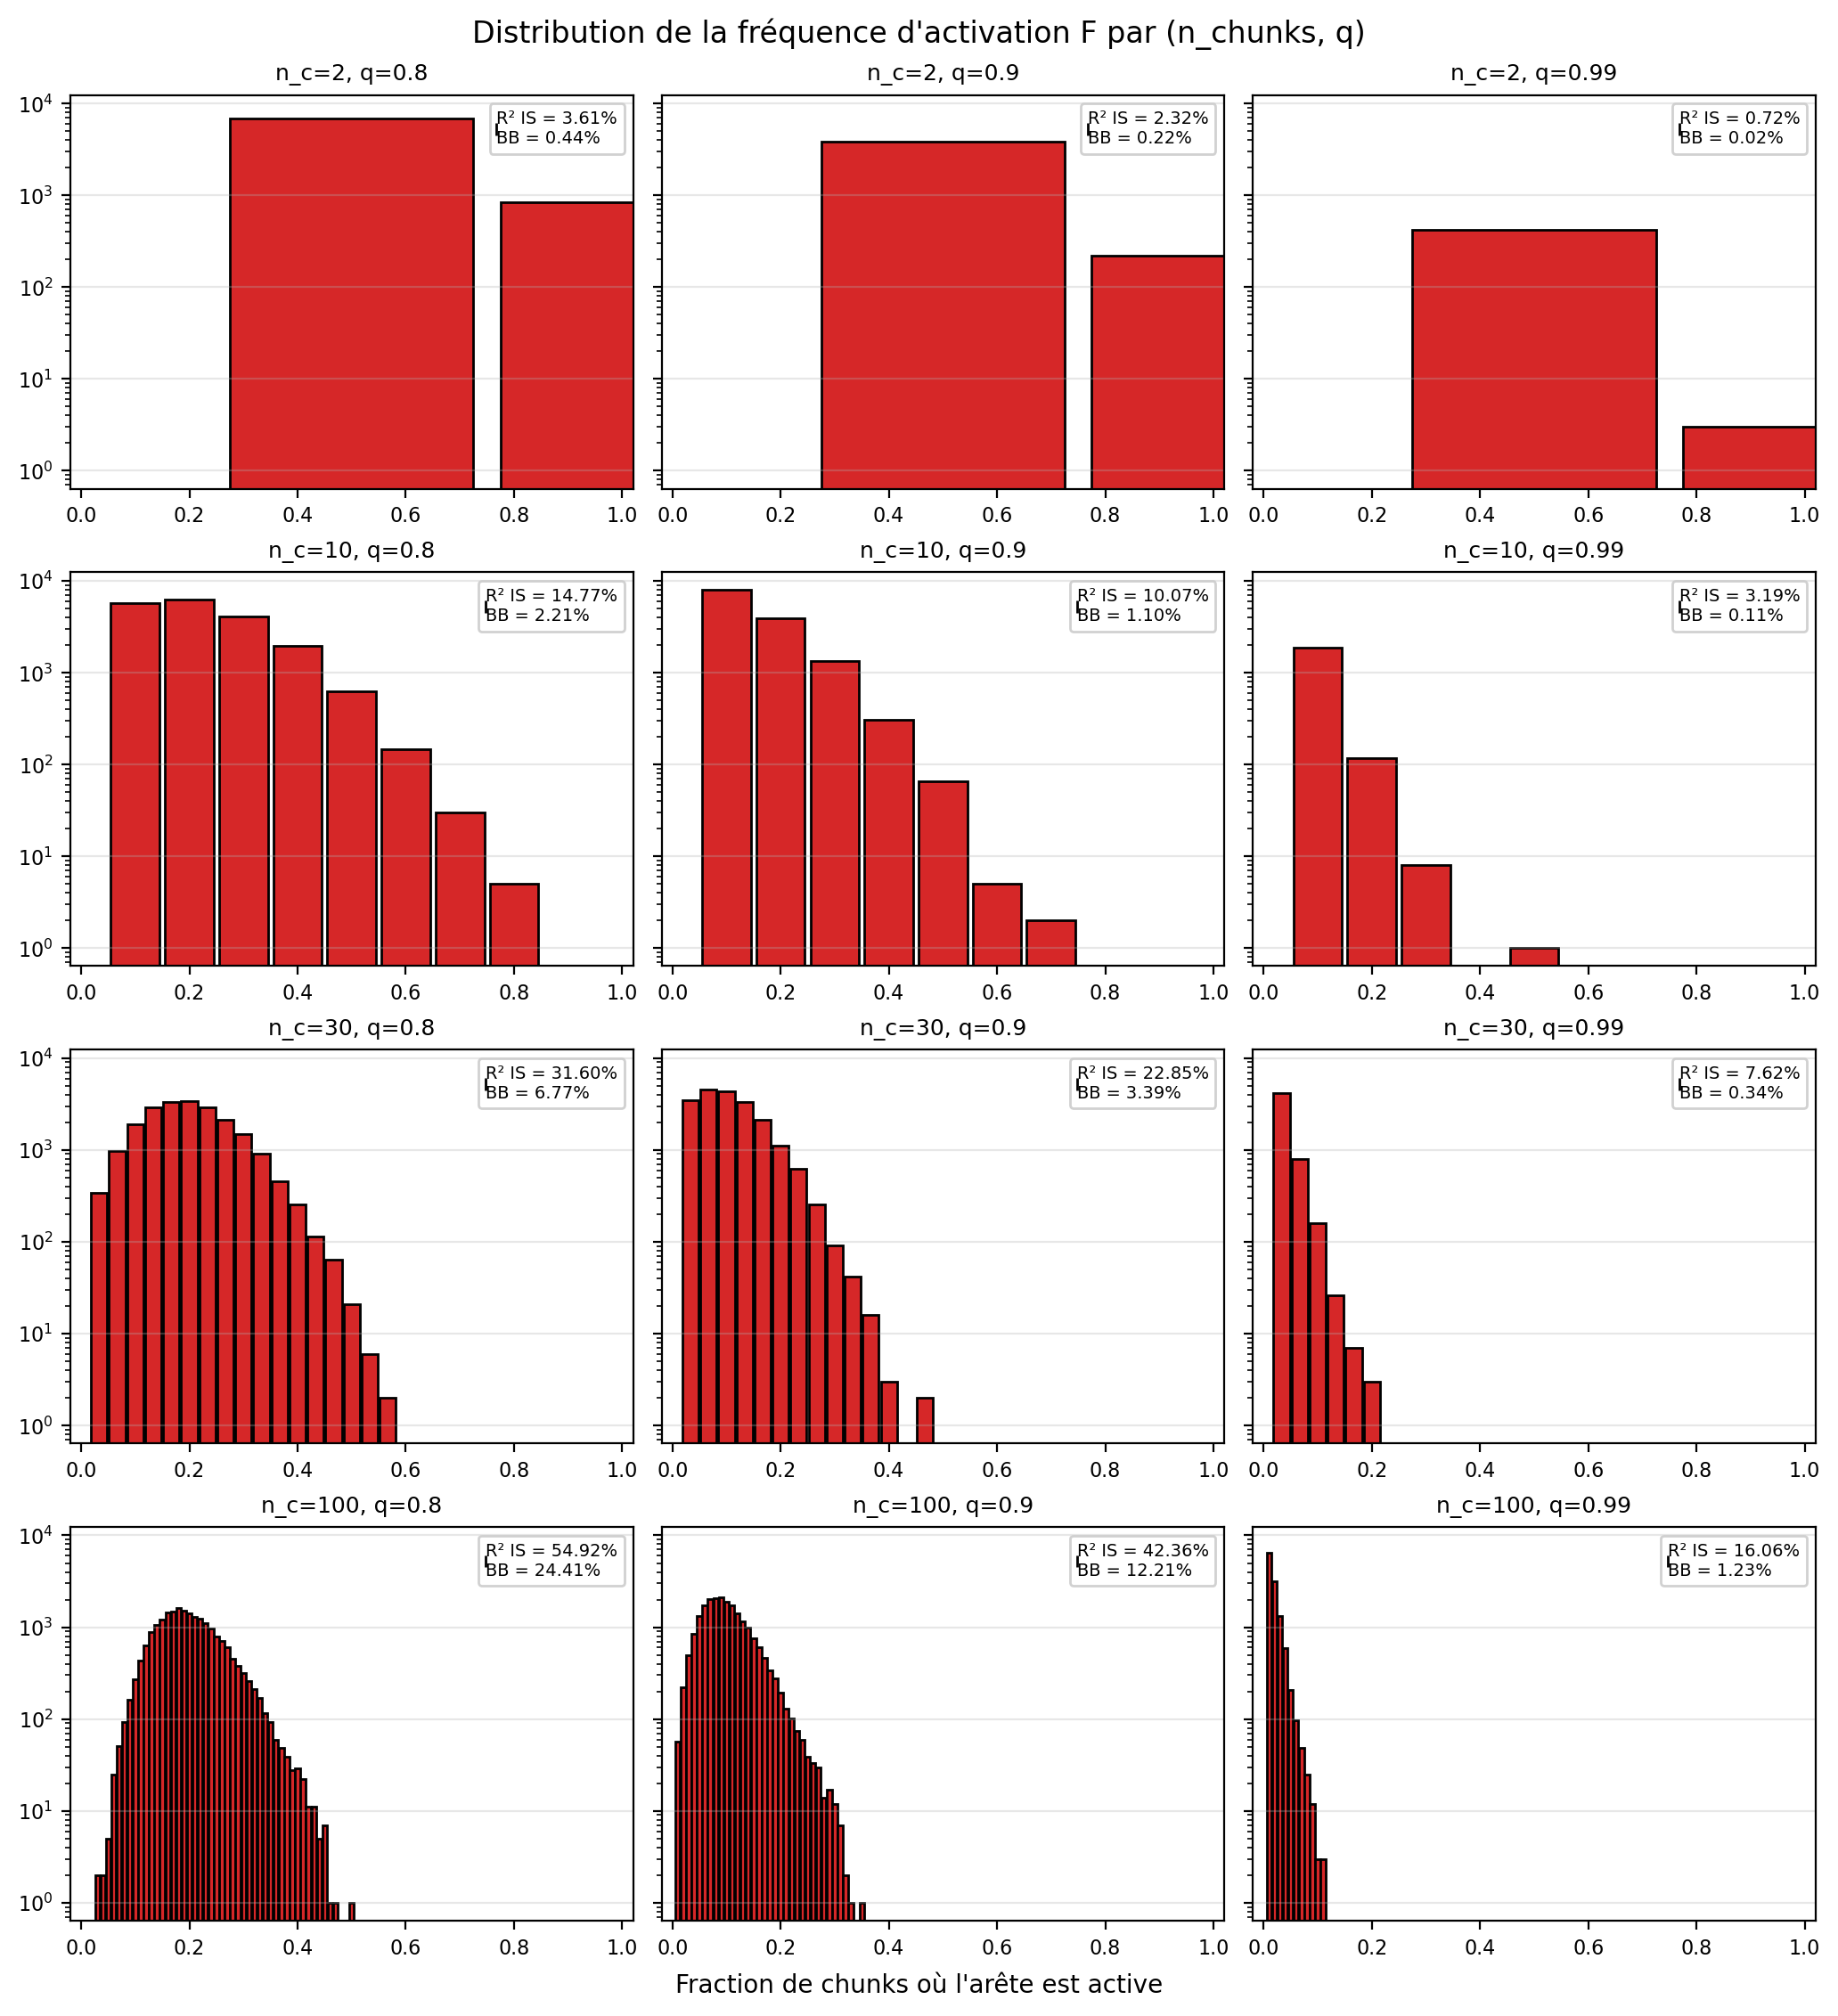

In [147]:
N_CHUNKS_LIST = [2, 10, 30, 100]
Q_LIST        = [0.80, 0.90, 0.99]

sweep = {}
for n_c in N_CHUNKS_LIST:
    chunks = np.array_split(real.values, n_c)
    for q in Q_LIST:
        r2s, r2_nulls, masks_list = [], [], []
        for ch in chunks:
            A_cst, mask, r2, r2_null = fit_sparse_chunk(ch, LAG_8, q)
            r2s.append(r2.mean()); r2_nulls.append(r2_null.mean())
            masks_list.append((A_cst != 0).astype(int))
        F = np.stack(masks_list, axis=0).mean(0)
        r2m, r2_nm = np.mean(r2s), np.mean(r2_nulls)
        sweep[(n_c, q)] = {'F': F, 'r2': r2m, 'r2_null': r2_nm}


# Grille des distributions de F (R² IS et baseline en légende)
fig, axes = plt.subplots(len(N_CHUNKS_LIST), len(Q_LIST),
                         figsize=(3.4*len(Q_LIST), 2.8*len(N_CHUNKS_LIST)),
                         constrained_layout=True, sharey=True)
for i, n_c in enumerate(N_CHUNKS_LIST):
    for j, q in enumerate(Q_LIST):
        ax = axes[i, j]
        s = sweep[(n_c, q)]
        F = s['F']
        F_vu = F[F > 0]
        xs = np.arange(1, n_c + 1) / n_c
        counts = [int(np.isclose(F_vu, x).sum()) for x in xs]
        ratio = s['r2'] / max(s['r2_null'], 1e-12)
        bar_label = (f'R² IS = {s["r2"]*100:.2f}%\n'
                     f'BB = {s["r2_null"]*100:.2f}%')
        ax.bar(xs, counts, width=0.9/n_c, color='#d62728', edgecolor='black',
               label=bar_label)
        ax.set_yscale('log')
        ax.set_title(f'n_c={n_c}, q={q}', fontsize=9)
        ax.legend(loc='upper right', fontsize=7, handlelength=0, handletextpad=0,
                  frameon=True, framealpha=0.9)
        ax.grid(alpha=0.3, axis='y')
        # Axe x : 6 ticks max, formatage décimal lisible
        ax.set_xlim(-0.02, 1.02)
        ticks = np.linspace(0, 1, 6)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f'{t:.1f}' for t in ticks])
        ax.tick_params(labelsize=8)

fig.suptitle("Distribution de la fréquence d'activation F par (n_chunks, q)",
             fontsize=12)
fig.supxlabel("Fraction de chunks où l'arête est active", fontsize=10)
plt.show()


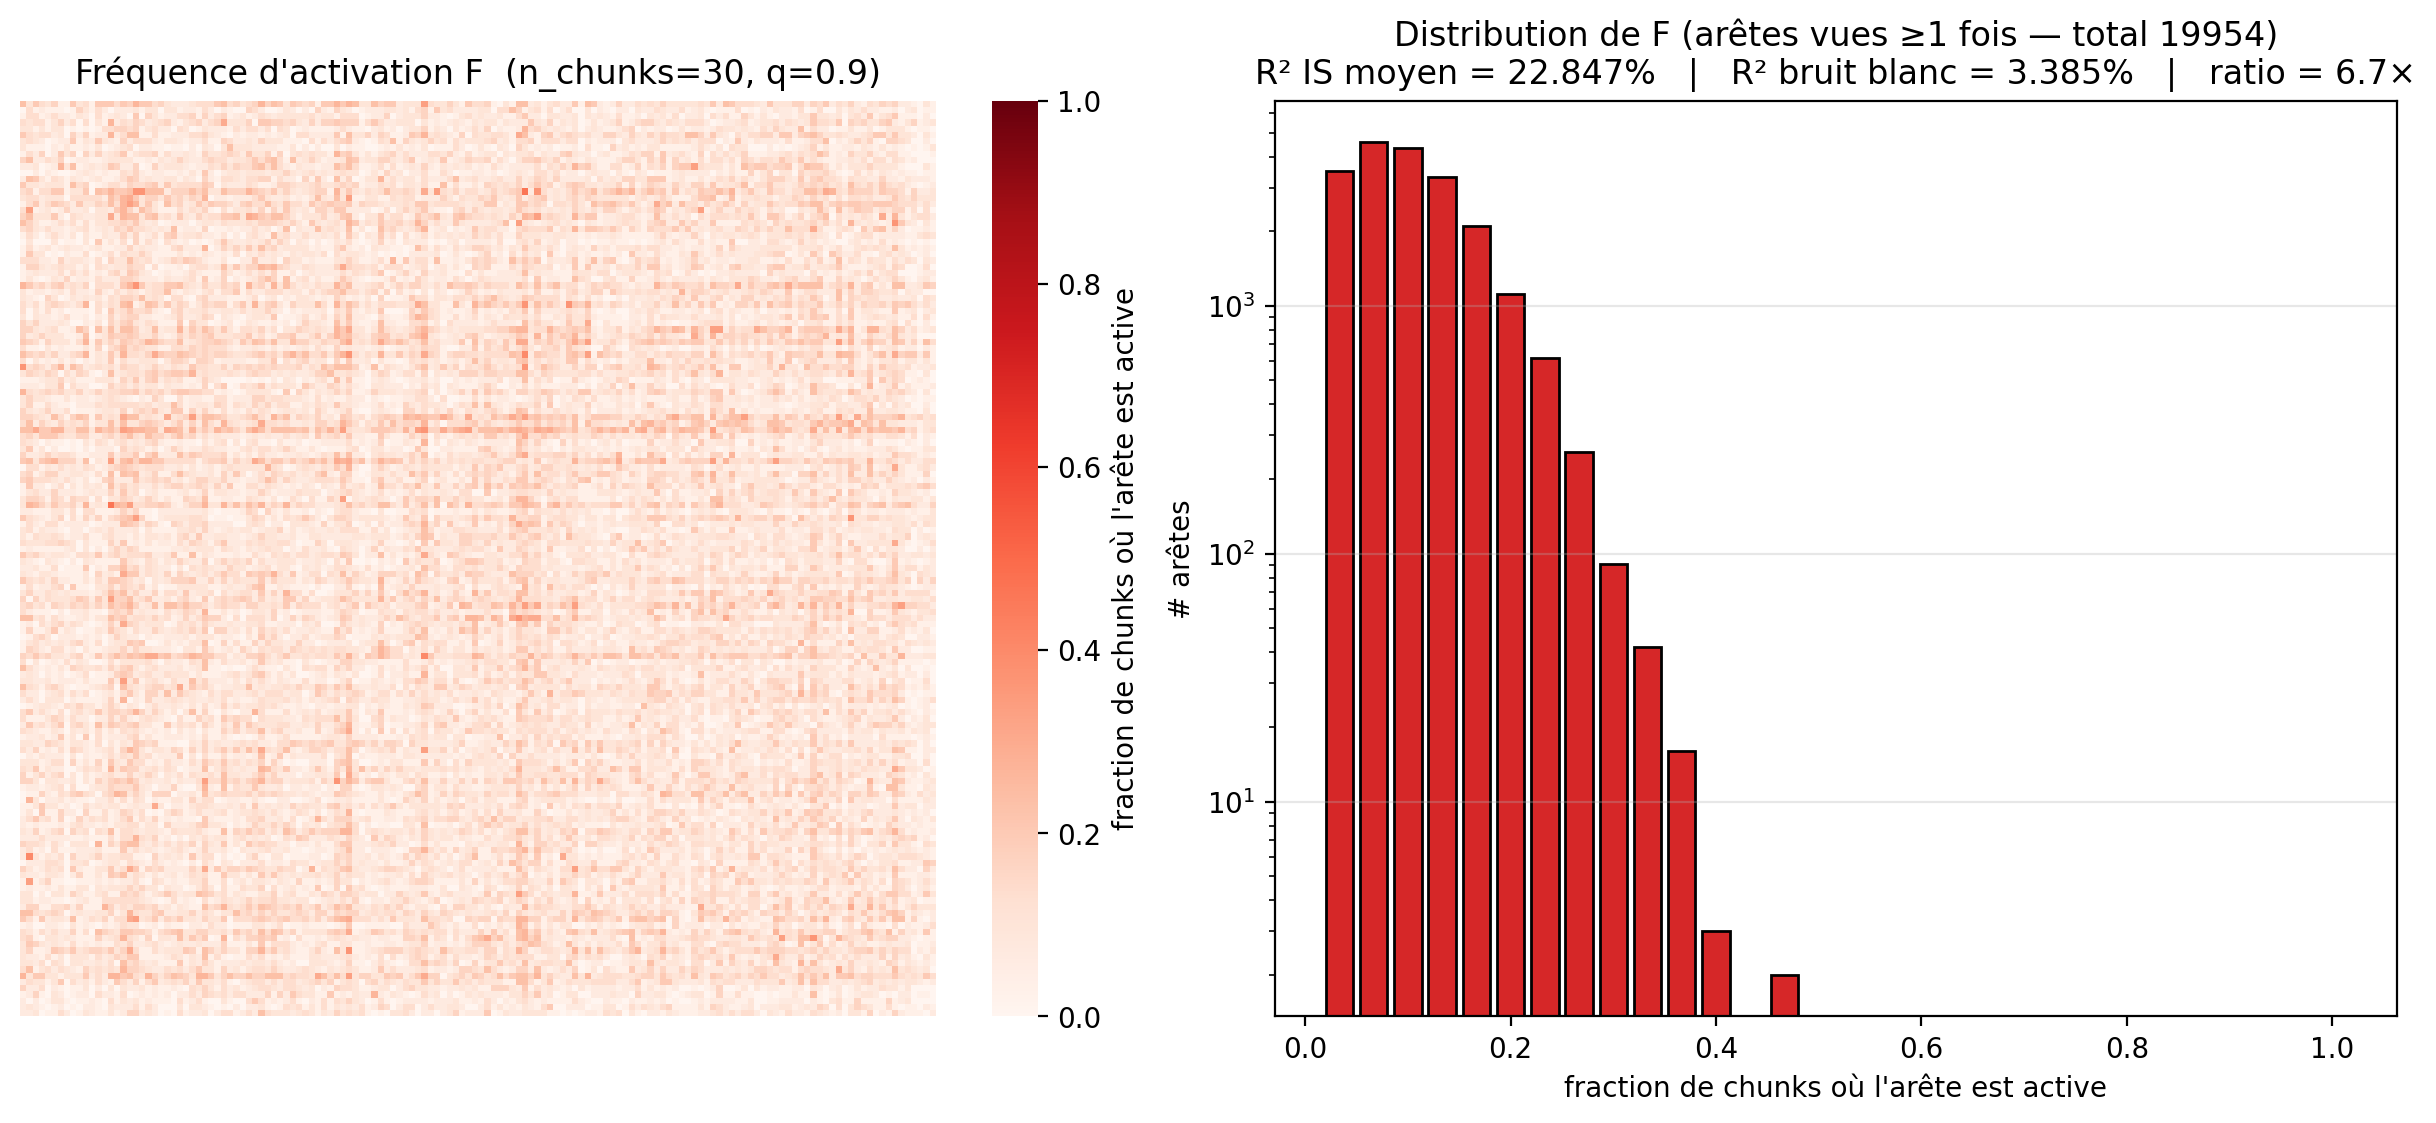

In [148]:
N_CHUNKS_DEF = 30
Q_DEF        = 0.9
chunks_def   = np.array_split(real.values, N_CHUNKS_DEF)

fits_def = []
r2_list, r2_null_list = [], []
for i, ch in enumerate(chunks_def):
    A_cst, mask, r2, r2_null = fit_sparse_chunk(ch, LAG_8, Q_DEF)
    fits_def.append((A_cst, mask))
    r2_list.append(r2.mean())
    r2_null_list.append(r2_null.mean())

r2_mean      = float(np.mean(r2_list))
r2_null_mean = float(np.mean(r2_null_list))
ratio        = r2_mean / max(r2_null_mean, 1e-12)


# ── Heatmap de la fréquence d'activation F = mean(A_cst != 0) ──────────
B = np.stack([(A != 0).astype(int) for A, _ in fits_def], axis=0)
F = B.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
sns.heatmap(F, cmap='Reds', vmin=0, vmax=1, ax=axes[0], square=True,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'fraction de chunks où l\'arête est active'})
axes[0].set_title(f'Fréquence d\'activation F  (n_chunks={N_CHUNKS_DEF}, q={Q_DEF})')

# Histogramme F sur arêtes vues au moins une fois
F_vu = F[F > 0]
xs = np.arange(1, N_CHUNKS_DEF + 1) / N_CHUNKS_DEF
counts = [(np.isclose(F_vu, x)).sum() for x in xs]
axes[1].bar(xs, counts, width=0.8/N_CHUNKS_DEF, color='#d62728', edgecolor='black')
axes[1].set_xlabel(f'fraction de chunks où l\'arête est active')
axes[1].set_ylabel('# arêtes')
axes[1].set_yscale('log')
axes[1].set_title(
    f'Distribution de F (arêtes vues ≥1 fois — total {(F>0).sum()})\n'
    f'R² IS moyen = {r2_mean*100:.3f}%   |   '
    f'R² bruit blanc = {r2_null_mean*100:.3f}%   |   ratio = {ratio:.1f}×'
)
axes[1].grid(alpha=0.3, axis='y')
plt.show()


In [149]:
adj = np.where(F > 0.35, 1, 0)  # seuil de 50% pour définir l'adjacence

<Axes: >

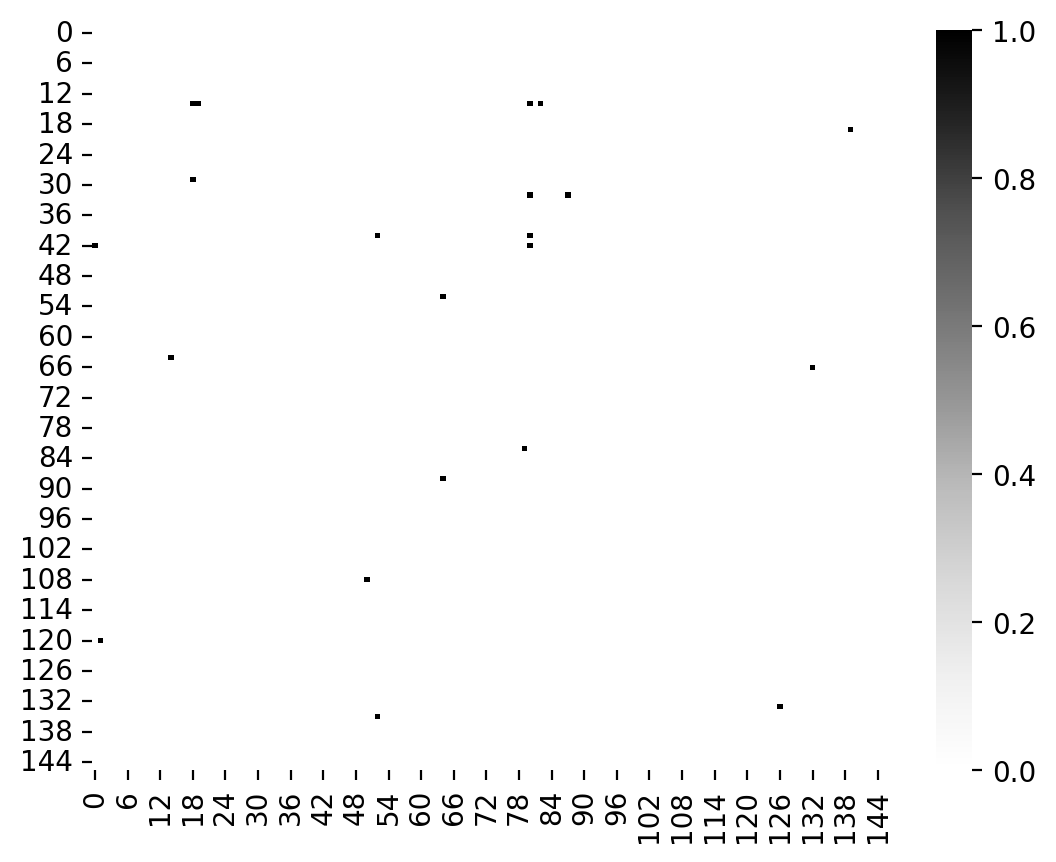

In [150]:
sns.heatmap(adj, cmap='Greys', vmin=0, vmax=1)

Isolés retirés : 121   |   actifs gardés : 25   |   arêtes : 21


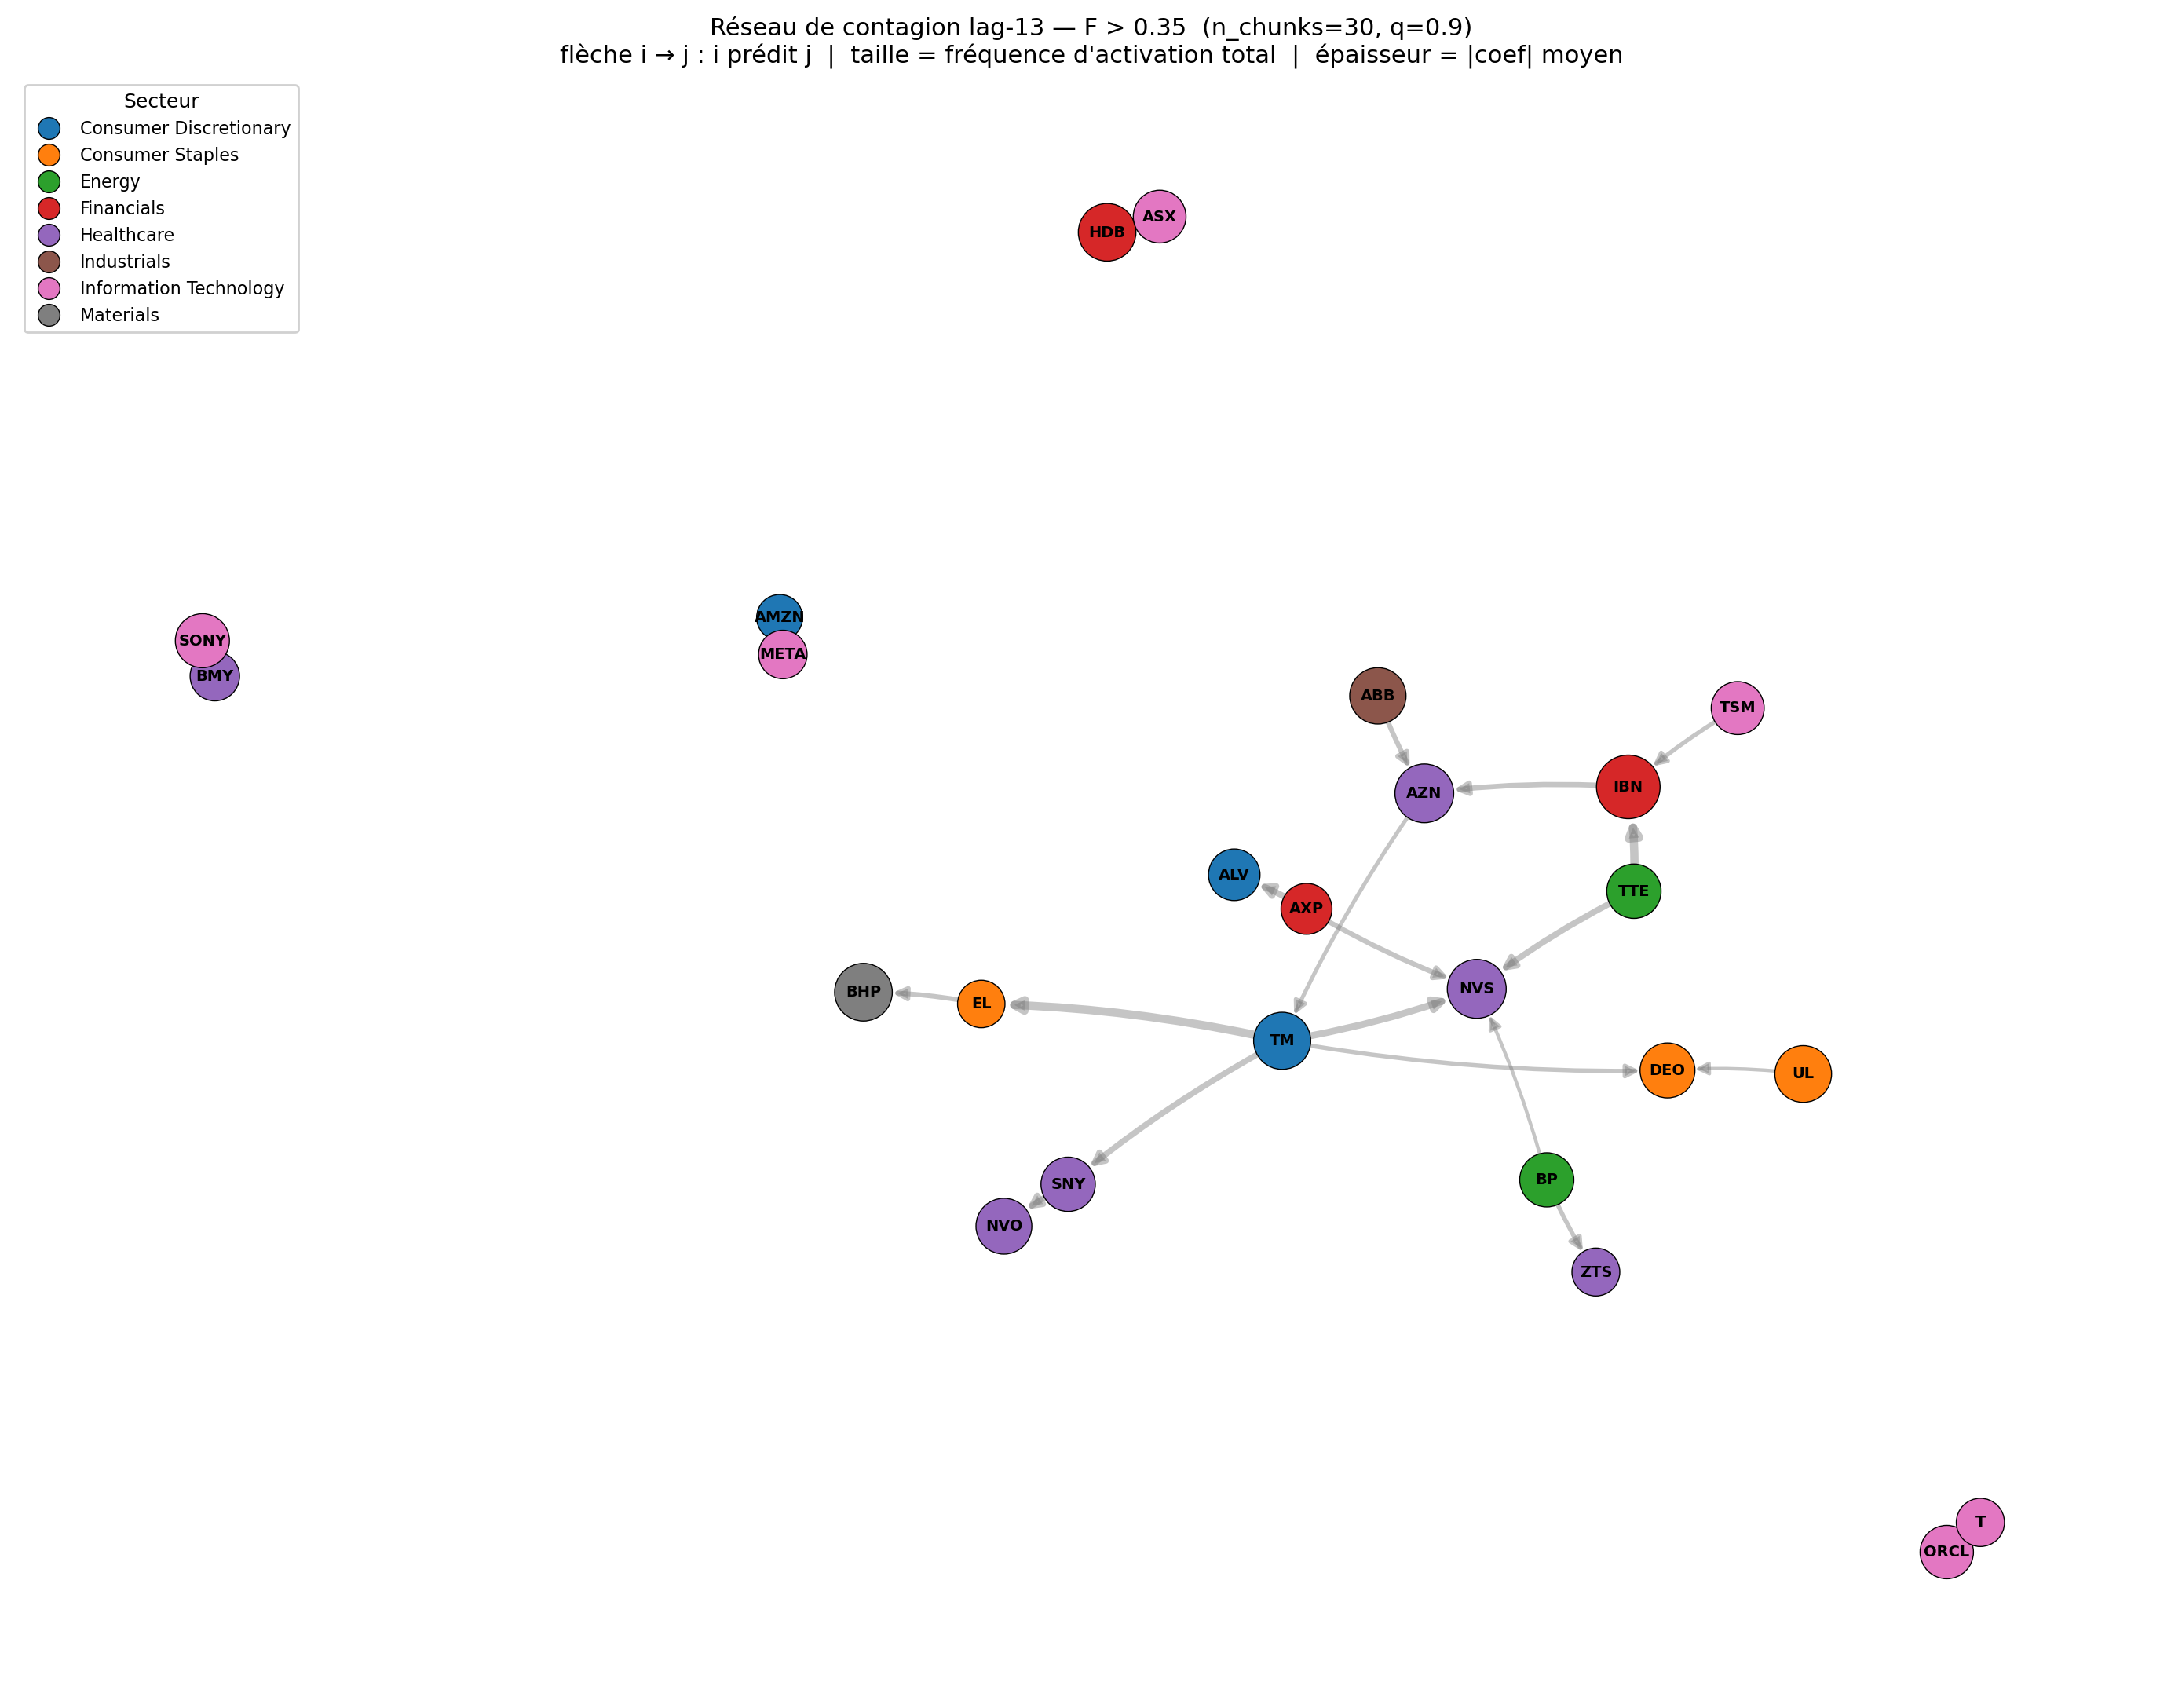

densité  : 0.0350


In [152]:
import networkx as nx
from fa2_modified import ForceAtlas2

# ── Adjacence binaire : seuil sur F ──────────────────────────────
SEUIL_F = 0.35
adj = (F > SEUIL_F).astype(int)
np.fill_diagonal(adj, 0)

# ── Pondération des arêtes : moyenne |A_cst| sur les chunks où active ──
# Convention : A_cst[i, j] = effet de r_i(t-lag) sur r_j(t)
# Donc arête i → j signifie "i prédit/cause j" (sens de contagion correct).
A_stack  = np.stack([A for A, _ in fits_def], axis=0)        # (n_chunks, N, N)
A_count  = (A_stack != 0).sum(axis=0)
A_meanW  = np.where(A_count > 0,
                    np.abs(A_stack).sum(axis=0) / np.maximum(A_count, 1),
                    0.0)

# ── Taille des noeuds : fréquence d'activation totale (out + in) ─
node_freq = F.sum(axis=1) + F.sum(axis=0)


# ── Graphe orienté + retrait des isolés ──────────────────────────
G = nx.from_numpy_array(adj, create_using=nx.DiGraph)
G = nx.relabel_nodes(G, {i: name for i, name in enumerate(asset_names)})
for i, name in enumerate(asset_names):
    G.nodes[name]['sector'] = sector_arr[i]
    G.nodes[name]['freq']   = node_freq[i]
for u, v in G.edges():
    iu = asset_names.index(u); iv = asset_names.index(v)
    G[u][v]['weight'] = A_meanW[iu, iv]

# Virer les actifs sans aucune connexion (in_degree + out_degree == 0)
isolated = [n for n in G.nodes() if G.in_degree(n) + G.out_degree(n) == 0]
G.remove_nodes_from(isolated)
print(f'Isolés retirés : {len(isolated)}   |   actifs gardés : {G.number_of_nodes()}   |   arêtes : {G.number_of_edges()}')


# ── Layout ForceAtlas2 ────────────────────────────────────────────
fa2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False,
)
pos = fa2.forceatlas2_networkx_layout(G.to_undirected(), pos=None, iterations=400)


# ── Couleurs et tailles ───────────────────────────────────────────
sectors_unique = sorted(set(G.nodes[n]['sector'] for n in G.nodes()))
cmap = plt.get_cmap('tab10' if len(sectors_unique) <= 10 else 'tab20')
sector_colors = {s: cmap(i % cmap.N) for i, s in enumerate(sectors_unique)}
node_colors = [sector_colors[G.nodes[n]['sector']] for n in G.nodes()]

freqs       = np.array([G.nodes[n]['freq'] for n in G.nodes()])
node_sizes  = 50 + 800 * (freqs / freqs.max())

weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
edge_widths = 0.3 + 3.5 * (weights / weights.max()) if weights.max() > 0 else 0.4


# ── Plot avec flèches pour montrer le sens i → j ─────────────────
fig, ax = plt.subplots(figsize=(14, 11))
nx.draw_networkx_edges(
    G, pos, ax=ax, width=edge_widths, alpha=0.45, edge_color='gray',
    arrows=True, arrowstyle='-|>', arrowsize=12,
    connectionstyle='arc3,rad=0.05', node_size=node_sizes,
)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, edgecolors='black', linewidths=0.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color='black',
                        font_weight='bold')

# Légende secteurs
patches = [plt.Line2D([0], [0], marker='o', color='w', label=s,
                      markerfacecolor=sector_colors[s], markersize=10,
                      markeredgecolor='black', markeredgewidth=0.5)
           for s in sectors_unique]
ax.legend(handles=patches, loc='upper left', fontsize=8, title='Secteur',
          title_fontsize=9, frameon=True, framealpha=0.9)

ax.set_title(
    f'Réseau de contagion lag-{LAG_8} — F > {SEUIL_F}  '
    f'(n_chunks={N_CHUNKS_DEF}, q={Q_DEF})\n'
    f'flèche i → j : i prédit j  |  taille = fréquence d\'activation total  |  '
    f'épaisseur = |coef| moyen',
    fontsize=11
)
ax.axis('off')
plt.tight_layout(); plt.show()

print(f'densité  : {G.number_of_edges() / max(G.number_of_nodes()*(G.number_of_nodes()-1), 1):.4f}')
